In [3]:
!pip install pandas numpy geopy scikit-learn

In [2]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("../../datasets/normalized_data/combined_normalized.csv")

In [5]:
df

,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Dist to CBD in Km,Sale Months Since Sep 2025,Num MRT Within 1km,Num Hawker Within 1km,Num Malls Within 1km,Num Hospitals Within 5km,Num Schools Within 2km,Num Parks Within 1km,Floor_Level_Category,Type_of_Sale_Encoded,Property_Type_Encoded,Market_Segment_Encoded,District
0,-0.211237,-0.460443,0.774350,1.347678,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,-1.619747,-1.228179,-0.334688,1.124971,1
1,-0.087630,-0.460443,1.240198,1.347678,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,0.947931,-1.228179,-0.334688,1.124971,1
2,-0.303362,-0.331436,-0.058154,-0.618881,-1.117103,-0.723616,-0.407922,0.640686,0.276567,-0.286674,0.161507,-0.152502,0.814214,2.987854,-0.888912,1
3,-0.100129,-0.442004,1.103809,1.347678,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,0.214309,-1.228179,-0.334688,1.124971,1
4,1.493910,2.267081,-0.950882,-0.363513,-1.117103,0.183604,-0.407922,0.156402,-0.670176,-0.286674,-0.030473,-1.619747,0.814214,-0.334688,-0.888912,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108367,0.046775,0.568074,-0.689954,-0.705343,1.573169,-0.762994,-0.374606,-1.216935,-1.442506,-1.156276,0.444833,1.136026,0.794933,0.657310,0.080720,28
108368,-0.016193,0.688792,-0.856036,-0.313104,1.573169,-0.287893,-0.374606,0.110836,0.451368,-0.384110,2.193072,-1.058519,0.794933,0.657310,0.080720,28
108369,-0.769843,1.443211,-1.977090,-0.350310,1.573169,-0.287893,-0.374606,-0.553049,0.451368,0.388056,-0.254463,-1.058519,0.794933,0.657310,0.080720,28
108370,0.656779,1.865669,-1.053869,-1.312109,1.573169,-1.238095,-0.374606,-1.216935,0.451368,-1.156276,-0.604110,-1.058519,0.794933,0.657310,-12.388450,28


In [5]:
df.isnull().values.any()


np.False_

## Simple Linear Regression

In [16]:
# --- single_feature_cv_metrics.py ---
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# CONFIG
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
# keep only existing columns
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 30    # skip feature if below this many rows after dropna
EPS = 1e-6       # avoid zero division in MAPE

def safe_mape(y_true, y_pred):
    # clip true values to avoid division by zero
    return mean_absolute_percentage_error(np.maximum(y_true, EPS), y_pred)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'r2_full': r2_score(y_true, y_pred),
        'rmse_full': mean_squared_error(y_true, y_pred, squared=False),
        'mae_full': mean_absolute_error(y_true, y_pred),
        'mape_full': safe_mape(y_true, y_pred)
    }

rows = []
for feature in feature_cols:
    sub = df[[feature, target_col]].dropna().copy()
    n = len(sub)
    if n < MIN_ROWS:
        print(f"Skipping '{feature}' — only {n} rows (< {MIN_ROWS})")
        continue

    # ensure numeric values
    try:
        X_full = sub[feature].astype(float).values.reshape(-1, 1)
        y_full = sub[target_col].astype(float).values
    except Exception as e:
        print(f"Skipping '{feature}' — conversion to float failed: {e}")
        continue

    # Fit on full data
    lr = LinearRegression()
    lr.fit(X_full, y_full)
    y_full_pred = lr.predict(X_full)
    full_metrics = compute_metrics(y_full, y_full_pred)

    # Cross-validated metrics
    # choose folds = min(CV_FOLDS, n) but require at least 2 folds
    n_splits = min(CV_FOLDS, n) if n >= 2 else 2
    # if too few samples for requested folds, reduce folds
    if n_splits < 2:
        print(f"Skipping CV for '{feature}' — insufficient samples: n={n}")
        continue

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_r2_list = []
    cv_rmse_list = []
    cv_mae_list = []
    cv_mape_list = []
    folds_used = 0

    for train_idx, val_idx in kf.split(X_full):
        X_tr, X_val = X_full[train_idx], X_full[val_idx]
        y_tr, y_val = y_full[train_idx], y_full[val_idx]

        # if y_tr is constant, r2 undefined in fold — still try; but skip if degenerate
        if np.unique(y_tr).size < 2:
            continue

        model = LinearRegression()
        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        cv_r2_list.append(r2_score(y_val, y_val_pred))
        cv_rmse_list.append(mean_squared_error(y_val, y_val_pred, squared=False))
        cv_mae_list.append(mean_absolute_error(y_val, y_val_pred))
        cv_mape_list.append(safe_mape(y_val, y_val_pred))
        folds_used += 1

    if folds_used == 0:
        print(f"No valid CV folds for '{feature}' (n={n}). Skipping feature.")
        continue

    row = {
        'feature': feature,
        'n': n,
        # full-sample
        'r2_full': full_metrics['r2_full'],
        'rmse_full': full_metrics['rmse_full'],
        'mae_full': full_metrics['mae_full'],
        'mape_full': full_metrics['mape_full'],
        # CV averages
        'cv_r2_mean': np.mean(cv_r2_list),
        'cv_r2_std': np.std(cv_r2_list),
        'cv_rmse_mean': np.mean(cv_rmse_list),
        'cv_mae_mean': np.mean(cv_mae_list),
        'cv_mape_mean': np.mean(cv_mape_list),
        'cv_folds_used': folds_used
    }
    rows.append(row)

results_df = pd.DataFrame(rows)
if results_df.empty:
    print("No features produced valid results. Check data and MIN_ROWS.")
else:
    # sort by cv_r2_mean descending
    results_df = results_df.sort_values('cv_r2_mean', ascending=False).reset_index(drop=True)

    # print results nicely
    pd.set_option('display.float_format', lambda x: f"{x:0.4f}")
    print("\n=== Single-feature linear regression results (sorted by CV R² mean) ===\n")
    display_cols = ['feature','n','r2_full','cv_r2_mean','cv_r2_std','cv_rmse_mean','cv_mae_mean','cv_mape_mean']
    print(results_df[display_cols].to_string(index=False))

    # best feature
    best = results_df.iloc[0]
    print("\n" + "="*60)
    print(f"Best feature: {best['feature']}")
    print(f"Samples: {int(best['n'])}")
    print(f"Full R² = {best['r2_full']:.4f}")
    print(f"CV R² mean = {best['cv_r2_mean']:.4f} (std {best['cv_r2_std']:.4f})")
    print(f"CV RMSE = {best['cv_rmse_mean']:.2f}, CV MAE = {best['cv_mae_mean']:.2f}, CV MAPE = {best['cv_mape_mean']:.4f}")
    print("="*60)

    # save to csv if desired
    results_df.to_csv("single_feature_cv_summary.csv", index=False)
    print("\nSaved summary to 'single_feature_cv_summary.csv'")



=== Single-feature linear regression results (sorted by CV R² mean) ===

                   feature      n  r2_full  cv_r2_mean  cv_r2_std  cv_rmse_mean  cv_mae_mean  cv_mape_mean
Sale Months Since Sep 2025 108372   0.0451      0.0467     0.0094        0.9780       0.6445   110845.2300
      Type_of_Sale_Encoded 108372   0.0364      0.0377     0.0076        0.9826       0.6509   100633.2934
      Floor_Level_Category 108372   0.0118      0.0119     0.0012        0.9954       0.6585    51541.7257
    Market_Segment_Encoded 108372   0.0062      0.0063     0.0010        0.9982       0.6602    22882.3286
  Num Hospitals Within 5km 108372   0.0043      0.0043     0.0005        0.9992       0.6603    29665.7735
         Dist to CBD in Km 108372   0.0033      0.0034     0.0006        0.9997       0.6604    27884.6035
     Property_Type_Encoded 108372   0.0009      0.0009     0.0005        1.0009       0.6613    15887.2656
     Num Hawker Within 1km 108372   0.0007      0.0007     0.0003     

## Simple Linear Regression by District

In [15]:
# --- Imports ---
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Config ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# --- Ensure required columns exist ---
for col in [target_col, 'District']:
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")

districts = sorted(df['District'].dropna().unique().astype(int))

# --- Container for results ---
district_results = []

# --- Step 1: Loop over districts ---
for dist in districts:
    df_dist = df[df['District'] == dist].copy()
    if len(df_dist) < 50:  # skip small districts with too few data points
        continue

    print(f"\n=== District {dist} (n={len(df_dist)}) ===")

    results = []
    for feature in feature_cols:
        subset = df_dist[[feature, target_col]].dropna()
        if subset.empty:
            continue
        X = subset[[feature]]
        y = subset[target_col]

        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        coef = model.coef_[0]
        r2 = r2_score(y, y_pred)

        results.append((feature, coef, r2))

    if not results:
        continue

    # Sort by R²
    results_df = (
        pd.DataFrame(results, columns=['Feature', 'Coefficient', 'R²'])
        .sort_values('R²', ascending=False)
        .reset_index(drop=True)
    )

    # Append to master list
    for _, row in results_df.iterrows():
        district_results.append({
            'District': dist,
            'Feature': row['Feature'],
            'Coefficient': row['Coefficient'],
            'R²': row['R²']
        })

    # Display top features for this district
    print("Top features by R²:\n", results_df.head(5), "\n")

# --- Step 2: Combine all district results ---
all_results_df = pd.DataFrame(district_results)

# Sort by district and then by R² descending
all_results_df = all_results_df.sort_values(['District', 'R²'], ascending=[True, False]).reset_index(drop=True)

# --- Step 3: Display summary ---
print("\n===== Summary of Feature Impact by District (Sorted by R²) =====\n")
print(all_results_df.head(30))  # preview top 30 rows

# --- Optional: Save to CSV for reporting ---
all_results_df.to_csv("district_feature_r2_summary.csv", index=False)
print("\nResults saved to 'district_feature_r2_summary.csv'")



=== District 1 (n=1638) ===
Top features by R²:
                       Feature  Coefficient        R²
0       Property_Type_Encoded     0.222569  0.049537
1        Floor_Level_Category     0.191947  0.036844
2      Market_Segment_Encoded    -0.114068  0.013012
3  Sale Months Since Sep 2025     0.082988  0.006887
4           Dist to CBD in Km    -0.078734  0.006199 


=== District 2 (n=1207) ===
Top features by R²:
                  Feature  Coefficient        R²
0   Floor_Level_Category     0.304769  0.091825
1   Num Malls Within 1km     0.299123  0.088130
2   Num Parks Within 1km     0.278287  0.077579
3  Num Hawker Within 1km     0.256005  0.065306
4     Num MRT Within 1km     0.249368  0.061074 


=== District 3 (n=4625) ===
Top features by R²:
                   Feature  Coefficient        R²
0  Num Schools Within 2km     0.374077  0.140932
1    Num Parks Within 1km     0.310704  0.093896
2    Type_of_Sale_Encoded    -0.260399  0.065975
3   Num Hawker Within 1km    -0.203794  0.04

## Multiple Linear Regression

#### 2 Features Combination between different amenities

In [ ]:
import itertools
import pandas as pd
import statsmodels.api as sm

# --- Configuration ---
target_col = 'Transacted Price ($)'

# Amenity-type independent variables
amenities = [
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km'
]

# --- Helper: Run regression and extract results ---
def run_ols(df, features, target):
    """Run OLS regression for a given feature set and return metrics"""
    subset = df[features + [target]].dropna()
    X = sm.add_constant(subset[features].astype(float), has_constant='add')
    y = subset[target].astype(float)

    model = sm.OLS(y, X).fit()
    sig_feats = model.pvalues[model.pvalues < 0.05].drop('const', errors='ignore').index.tolist()
    
    return {
        'features': features,
        'n': len(subset),
        'r2': model.rsquared,
        'adj_r2': model.rsquared_adj,
        'sig_features': sig_feats,
        'pvalues': model.pvalues.to_dict(),
        'params': model.params.to_dict()
    }

# --- Run pairwise (2-feature) combinations ---
results = []
for combo in itertools.combinations(amenities, 2):
    res = run_ols(df, list(combo), target_col)
    # keep only models with at least one significant feature
    if len(res['sig_features']) > 0:
        results.append(res)

# --- Convert to DataFrame ---
results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values('adj_r2', ascending=False).reset_index(drop=True)

    print(f"\n===== Significant 2-feature Models (p < 0.05) =====\n")
    for _, row in results_df.iterrows():
        print(f"Features: {', '.join(row['features'])}")
        print(f"Significant: {', '.join(row['sig_features'])}")
        print(f"R² = {row['r2']:.3f}, Adjusted R² = {row['adj_r2']:.3f}, n = {row['n']}")
        for feat in row['sig_features']:
            coef = row['params'][feat]
            pval = row['pvalues'][feat]
            print(f"  → {feat}: coef = {coef:.2f}, p = {pval:.4f}")
        print("-" * 70)

    print(f"\nTop combinations by Adjusted R²:\n")
    print(results_df[['features', 'adj_r2', 'sig_features']].head(10))
else:
    print("No 2-feature combinations found with significant coefficients (p < 0.05).")



===== Significant 2-feature Models (p < 0.05) =====

Features: Num Hospitals Within 5km, Num Parks Within 1km
Significant: Num Hospitals Within 5km, Num Parks Within 1km
R² = 0.005, Adjusted R² = 0.005, n = 112981
  → Num Hospitals Within 5km: coef = 0.07, p = 0.0000
  → Num Parks Within 1km: coef = 0.02, p = 0.0000
----------------------------------------------------------------------
Features: Num Hawker Within 1km, Num Hospitals Within 5km
Significant: Num Hawker Within 1km, Num Hospitals Within 5km
R² = 0.005, Adjusted R² = 0.005, n = 112981
  → Num Hawker Within 1km: coef = -0.02, p = 0.0000
  → Num Hospitals Within 5km: coef = 0.07, p = 0.0000
----------------------------------------------------------------------
Features: Num Malls Within 1km, Num Hospitals Within 5km
Significant: Num Hospitals Within 5km
R² = 0.004, Adjusted R² = 0.004, n = 112981
  → Num Hospitals Within 5km: coef = 0.07, p = 0.0000
----------------------------------------------------------------------
Featur

## Combinations of 2-12 Features

In [ ]:
# --- exhaustive_combinations_regression.py ---
import itertools
import math
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- CONFIG ---
df_work = df.copy()                       # your dataframe
target_col = 'Transacted Price ($)'       # target
# candidate features (ensure these exist in df)
candidate_features = [
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'District'
]
# filter to only columns in df
candidate_features = [c for c in candidate_features if c in df_work.columns]

# parameters
MIN_ROWS_PER_MODEL = lambda k: max(40, 5 * k)   # require at least this many rows for the combo
CV_FOLDS = 5
RANDOM_STATE = 42
USE_TQDM = True

# (Optional) limit number combos per k for very large feature sets (set None to run all)
max_combinations_per_k = None  # e.g. 1000 to cap, or None to allow all

# --- helper: compute metrics from true/pred arrays ---
def compute_metrics(y_true, y_pred):
    # ensure numpy arrays
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # handle MAPE edge cases: sklearn's MAPE will error if y_true contains zeros badly scaled; add small eps
    eps = 1e-6
    mape = mean_absolute_percentage_error(np.maximum(y_true, eps), y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}

# --- main loop ---
all_summary = []   # store all combos summary for later ranking
best_per_k = {}    # store best combo for each k

# iterate k = 2 .. min(12, number of available features)
max_k = min(12, len(candidate_features))
for k in range(2, max_k + 1):
    combos = list(itertools.combinations(candidate_features, k))
    if max_combinations_per_k is not None and len(combos) > max_combinations_per_k:
        combos = combos[:max_combinations_per_k]  # limit for performance
    comb_iter = tqdm(combos, desc=f"k={k}", ncols=80) if USE_TQDM else combos

    best_combo_for_k = None
    best_cv_r2 = -np.inf

    for combo in comb_iter:
        combo = list(combo)
        sub = df_work[combo + [target_col]].dropna()
        n = len(sub)
        if n < MIN_ROWS_PER_MODEL(k):
            # insufficient samples for this combo; skip
            continue

        X_full = sub[combo].astype(float).values
        y_full = sub[target_col].astype(float).values

        # Fit on full sample (for full-sample R2)
        lr = LinearRegression()
        try:
            lr.fit(X_full, y_full)
        except Exception:
            continue
        y_full_pred = lr.predict(X_full)
        metrics_full = compute_metrics(y_full, y_full_pred)

        # Cross-validation metrics
        kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_r2s = []
        cv_rmses = []
        cv_maes = []
        cv_mapes = []
        fold_count = 0
        for tr_idx, val_idx in kf.split(X_full, y_full):
            X_tr, X_val = X_full[tr_idx], X_full[val_idx]
            y_tr, y_val = y_full[tr_idx], y_full[val_idx]
            # need to ensure training set has variance
            if np.unique(y_tr).shape[0] < 2:
                continue
            model_cv = LinearRegression()
            try:
                model_cv.fit(X_tr, y_tr)
                y_val_pred = model_cv.predict(X_val)
            except Exception:
                continue
            m = compute_metrics(y_val, y_val_pred)
            cv_r2s.append(m['r2'])
            cv_rmses.append(m['rmse'])
            cv_maes.append(m['mae'])
            cv_mapes.append(m['mape'])
            fold_count += 1

        if fold_count == 0:
            continue

        cv_r2_mean = np.mean(cv_r2s)
        cv_r2_std = np.std(cv_r2s)
        cv_rmse_mean = np.mean(cv_rmses)
        cv_mae_mean = np.mean(cv_maes)
        cv_mape_mean = np.mean(cv_mapes)

        record = {
            'k': k,
            'features': combo,
            'n': n,
            # full-sample metrics (on training)
            'r2_full': metrics_full['r2'],
            'rmse_full': metrics_full['rmse'],
            'mae_full': metrics_full['mae'],
            'mape_full': metrics_full['mape'],
            # CV metrics (mean across folds)
            'cv_r2_mean': cv_r2_mean,
            'cv_r2_std': cv_r2_std,
            'cv_rmse_mean': cv_rmse_mean,
            'cv_mae_mean': cv_mae_mean,
            'cv_mape_mean': cv_mape_mean,
            'folds_used': fold_count
        }
        all_summary.append(record)

        # track best by cv_r2_mean for this k
        if cv_r2_mean > best_cv_r2:
            best_cv_r2 = cv_r2_mean
            best_combo_for_k = record

    # store best for this k
    if best_combo_for_k is not None:
        best_per_k[k] = best_combo_for_k
        # print best combo for this k (formatted)
        print("\n" + "="*70)
        print(f"Best combo for k={k}  (CV R² mean = {best_combo_for_k['cv_r2_mean']:.4f})")
        print("Features:", best_combo_for_k['features'])
        print(f"n = {best_combo_for_k['n']}, folds used = {best_combo_for_k['folds_used']}")
        print(f"Full R² = {best_combo_for_k['r2_full']:.4f}")
        print(f"CV RMSE = {best_combo_for_k['cv_rmse_mean']:.2f}, CV MAE = {best_combo_for_k['cv_mae_mean']:.2f}, CV MAPE = {best_combo_for_k['cv_mape_mean']:.4f}")
        print("="*70)
    else:
        print(f"\nNo valid combos found for k={k} (insufficient data or numeric issues).")

# --- final summary: choose overall best combo across all k by cv_r2_mean ---
if len(all_summary) == 0:
    print("\nNo models were fitted (check MIN_ROWS_PER_MODEL or data completeness).")
else:
    all_df = pd.DataFrame(all_summary)
    all_df_sorted = all_df.sort_values('cv_r2_mean', ascending=False).reset_index(drop=True)
    overall_best = all_df_sorted.iloc[0]
    print("\n" + "#" * 80)
    print("OVERALL BEST COMBINATION (ranked by CV R² mean):")
    print(f"k = {overall_best['k']}, features = {overall_best['features']}")
    print(f"n = {overall_best['n']}, folds used = {overall_best['folds_used']}")
    print(f"Full R² = {overall_best['r2_full']:.4f}")
    print(f"CV R² mean = {overall_best['cv_r2_mean']:.4f} (std {overall_best['cv_r2_std']:.4f})")
    print(f"CV RMSE = {overall_best['cv_rmse_mean']:.2f}, CV MAE = {overall_best['cv_mae_mean']:.2f}, CV MAPE = {overall_best['cv_mape_mean']:.4f}")
    print("#" * 80)

    # Save the detailed results for inspection
    all_df_sorted.to_csv("combination_search_results_by_cv_r2.csv", index=False)
    print("\nSaved full results to 'combination_search_results_by_cv_r2.csv'")


k=2: 100%|██████████████████████████████████████| 78/78 [00:04<00:00, 17.02it/s]



Best combo for k=2  (CV R² mean = 0.0875)
Features: ['Sale Months Since Sep 2025', 'Type_of_Sale_Encoded']
n = 108372, folds used = 5
Full R² = 0.0845
CV RMSE = 0.96, CV MAE = 0.64, CV MAPE = 133063.6133


k=3: 100%|████████████████████████████████████| 286/286 [00:18<00:00, 15.49it/s]



Best combo for k=3  (CV R² mean = 0.0958)
Features: ['Sale Months Since Sep 2025', 'Type_of_Sale_Encoded', 'Property_Type_Encoded']
n = 108372, folds used = 5
Full R² = 0.0925
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 140573.0670


k=4: 100%|████████████████████████████████████| 715/715 [00:55<00:00, 12.99it/s]


...


Best combo for k=10  (CV R² mean = 0.1081)
Features: ['Num MRT Within 1km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1049
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 150170.0828


k=11: 100%|█████████████████████████████████████| 78/78 [00:20<00:00,  3.83it/s]



Best combo for k=11  (CV R² mean = 0.1083)
Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1051
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 150092.1636


k=12: 100%|█████████████████████████████████████| 13/13 [00:04<00:00,  2.81it/s]


Best combo for k=12  (CV R² mean = 0.1083)
Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1051
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 149994.1243

################################################################################
OVERALL BEST COMBINATION (ranked by CV R² mean):
k = 12, features = ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1051
CV R² mean = 0.1083 (std 0.0193)
CV RMSE = 0.95, CV MAE

## Standardized Coefficients


===== Standardized Coefficients (All Features) =====

                       Feature  Standardized_Coefficient  \
0   Sale Months Since Sep 2025                   -0.2159   
1         Type_of_Sale_Encoded                   -0.2124   
2        Property_Type_Encoded                    0.0862   
3         Floor_Level_Category                    0.0703   
4       Market_Segment_Encoded                   -0.0682   
5        Num Hawker Within 1km                   -0.0354   
6         Num Malls Within 1km                    0.0344   
7     Num Hospitals Within 5km                    0.0318   
8         Num Parks Within 1km                    0.0266   
9           Num MRT Within 1km                   -0.0161   
10      Num Schools Within 2km                    0.0139   
11           Dist to CBD in Km                    0.0062   

    $ Impact per 1 SD increase  \
0                      -0.2171   
1                      -0.2135   
2                       0.0867   
3                       0.07

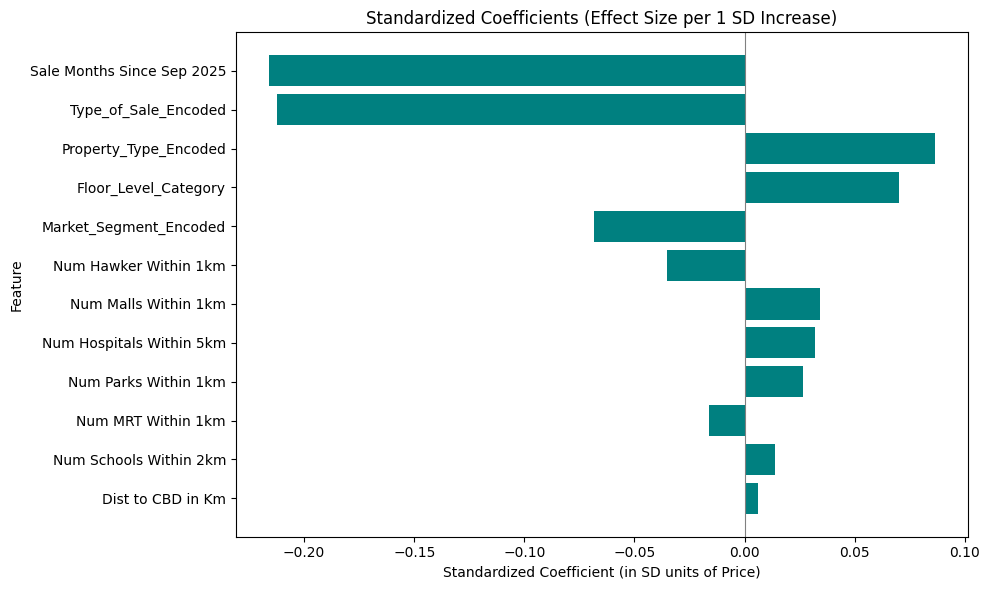


Model R²: 0.10512287685640909
Adjusted R²: 0.10502377548524722

Significant features (p < 0.05):
[0.00000000e+000 5.20879406e-007 1.85670907e-031 4.37444514e-026
 5.99256692e-019 9.04171570e-006 2.80543981e-019 3.25339178e-127
 0.00000000e+000 6.57209753e-174 1.60274914e-101]


In [17]:
# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# --- Config ---
target_col = 'Transacted Price ($)'

# Features to include (ensure these exist in df)
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# --- Step 1: Drop NaNs and prepare data ---
subset = df[feature_cols + [target_col]].dropna()
X = subset[feature_cols].astype(float)
y = subset[target_col].astype(float)

# --- Step 2: Standardize predictors and dependent variable ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# --- Step 3: Fit standardized OLS model ---
X_sm = sm.add_constant(X_scaled, has_constant='add')
model = sm.OLS(y_scaled, X_sm).fit()

# --- Step 4: Extract standardized coefficients and stats ---
coef_df = pd.DataFrame({
    'Feature': ['Intercept'] + feature_cols,
    'Standardized_Coefficient': model.params
})

# remove intercept row
coef_df = coef_df[coef_df['Feature'] != 'Intercept']

# absolute importance (for ranking)
coef_df['Abs_Coefficient'] = coef_df['Standardized_Coefficient'].abs()

# sort descending by absolute effect size
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

# --- Step 5: Interpretable version (in dollars per SD change) ---
# Convert standardized effect back to actual $ change per 1 SD increase in feature
# (multiply standardized coefficient * std of y)
std_y = np.std(y)
coef_df['$ Impact per 1 SD increase'] = coef_df['Standardized_Coefficient'] * std_y
coef_df['Interpretation'] = coef_df.apply(
    lambda row: f"1 SD increase in {row['Feature']} → ${row['$ Impact per 1 SD increase']:.0f} change in price",
    axis=1
)

# --- Step 6: Print Results ---
print("\n===== Standardized Coefficients (All Features) =====\n")
print(coef_df[['Feature', 'Standardized_Coefficient', '$ Impact per 1 SD increase', 'Interpretation']])

# --- Step 7: Optional — visualize effect sizes ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Standardized_Coefficient'], color='teal')
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Standardized Coefficients (Effect Size per 1 SD Increase)")
plt.xlabel("Standardized Coefficient (in SD units of Price)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Optional: Model performance summary ---
print("\nModel R²:", model.rsquared)
print("Adjusted R²:", model.rsquared_adj)
print("\nSignificant features (p < 0.05):")
print(model.pvalues[model.pvalues < 0.05])


## Non-linear Modelling

## XGBoost

In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



===== Full Sample Metrics =====
R2: 0.9823
RMSE: 0.1338
MAE: 0.0861
MAPE: 322663.8803

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.8323
CV_R2_std: 0.0906
CV_RMSE_mean: 0.4052
CV_MAE_mean: 0.1012
CV_MAPE_mean: 322374.8953

===== Top Features by Importance =====
                   Feature  Importance
               Area (SQFT)    0.252692
    Market_Segment_Encoded    0.181389
      Type_of_Sale_Encoded    0.169167
        Num MRT Within 1km    0.061816
Sale Months Since Sep 2025    0.055884
      Num Malls Within 1km    0.055146
     Property_Type_Encoded    0.051031
     Num Hawker Within 1km    0.042385
  Num Hospitals Within 5km    0.039065
      Num Parks Within 1km    0.026836


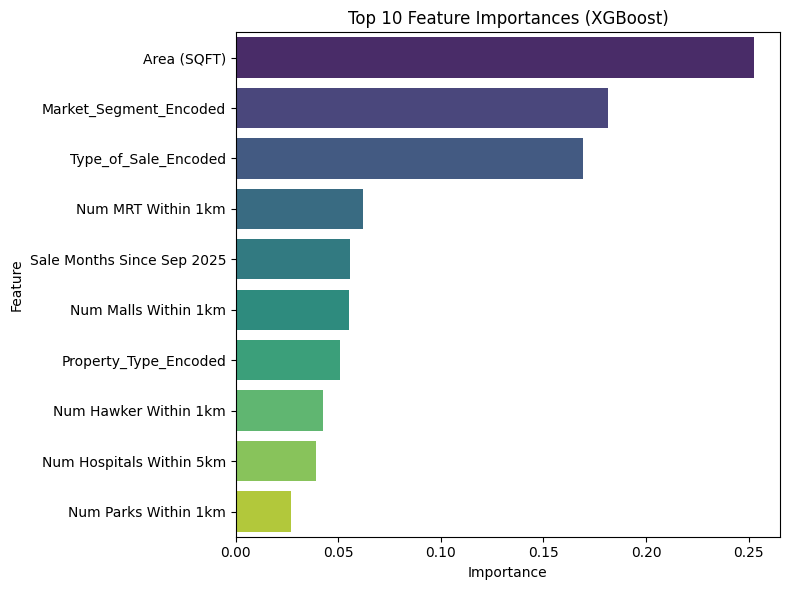


===== XGBoost Model Summary =====
R2: 0.9823
RMSE: 0.1338
MAE: 0.0861
MAPE: 322663.8803
CV_R2_mean: 0.8323
CV_R2_std: 0.0906
CV_RMSE_mean: 0.4052
CV_MAE_mean: 0.1012
CV_MAPE_mean: 322374.8953


In [13]:
# --- XGBoost Regression with CV and Scoring ---
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'Area (SQFT)'
]
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# --- Safe metrics ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Prepare Data ---
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# --- XGBoost Configuration ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Full-Sample Fit ---
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# --- Cross-Validation Metrics ---
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

# --- Aggregate CV Results ---
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# --- Feature Importance ---
import matplotlib.pyplot as plt
import seaborn as sns

importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\n===== Top Features by Importance =====")
print(feat_imp_df.head(10).to_string(index=False))

# --- Plot Feature Importances ---
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# --- Summary Output ---
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")



===== Full Sample Metrics =====
R2: 0.9823
RMSE: 0.1338
MAE: 0.0861
MAPE: 322663.8803
Fold 1 metrics: R2=0.8844, RMSE=0.3143, MAE=0.0980, MAPE=321844.1110
Fold 2 metrics: R2=0.6814, RMSE=0.6547, MAE=0.1053, MAPE=324555.9814
Fold 3 metrics: R2=0.9136, RMSE=0.2728, MAE=0.0999, MAPE=320213.0647
Fold 4 metrics: R2=0.7745, RMSE=0.4941, MAE=0.1033, MAPE=322859.5142
Fold 5 metrics: R2=0.9075, RMSE=0.2900, MAE=0.0996, MAPE=322401.8050

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.8323
CV_R2_std: 0.0906
CV_RMSE_mean: 0.4052
CV_MAE_mean: 0.1012
CV_MAPE_mean: 322374.8953

===== Full Feature Importance Ranking =====
                   Feature  Importance  Importance_Norm  Importance_Cum
               Area (SQFT)    0.252692         0.252693        0.252693
    Market_Segment_Encoded    0.181389         0.181389        0.434082
      Type_of_Sale_Encoded    0.169167         0.169167        0.603249
        Num MRT Within 1km    0.061816         0.061816        0.665065
Sale Months 

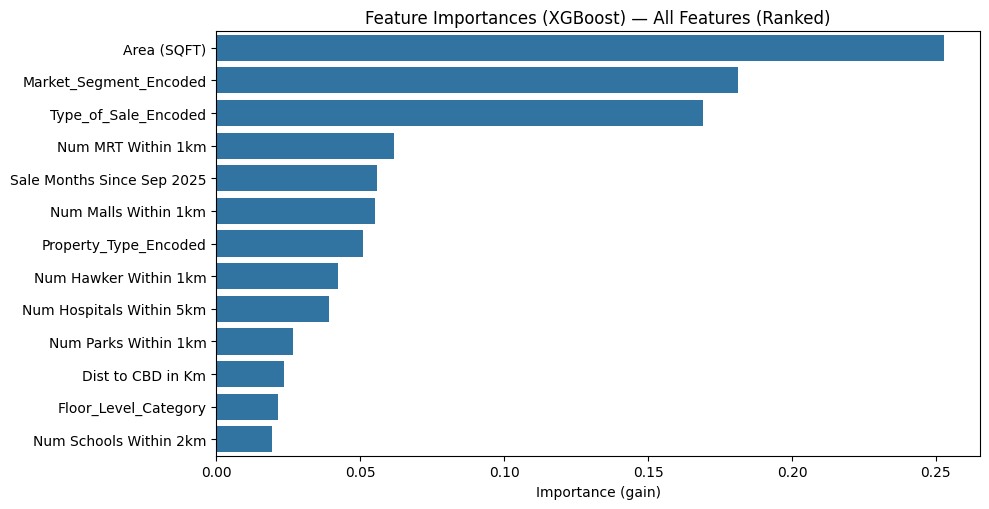

<Figure size 640x480 with 0 Axes>

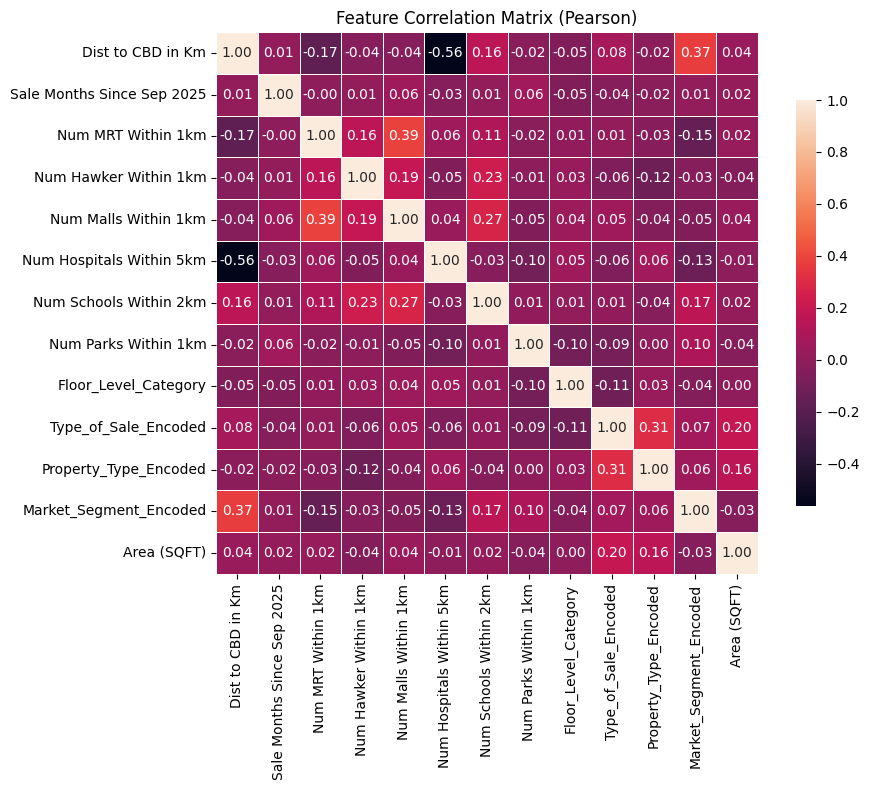

<Figure size 640x480 with 0 Axes>

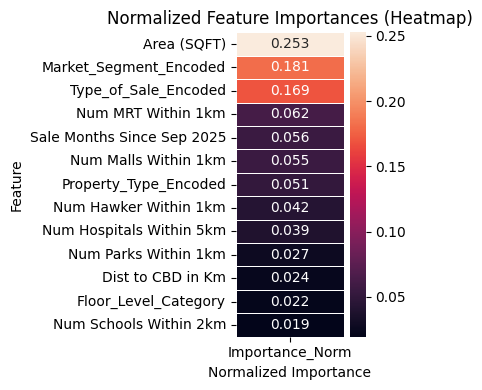


===== XGBoost Model Summary =====
R2: 0.9823
RMSE: 0.1338
MAE: 0.0861
MAPE: 322663.8803
CV_R2_mean: 0.8323
CV_R2_std: 0.0906
CV_RMSE_mean: 0.4052
CV_MAE_mean: 0.1012
CV_MAPE_mean: 322374.8953


<Figure size 640x480 with 0 Axes>

In [6]:
# xgboost_full_with_all_importances_and_heatmaps.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'Area (SQFT)'
]

# Remove features not present in df (keeps behavior from your script)
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# --- Safe metrics ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Prepare Data ---
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# --- XGBoost Configuration ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Full-Sample Fit ---
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# --- Cross-Validation Metrics ---
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for fold_id, (train_idx, val_idx) in enumerate(kf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

    print(f"Fold {fold_id} metrics: R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, MAPE={m['MAPE']:.4f}")

# --- Aggregate CV Results ---
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# --- Feature Importance (full ranking) ---
importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
})

# Sort descending
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Add normalized and cumulative importance columns
total_imp = feat_imp_df['Importance'].sum() if feat_imp_df['Importance'].sum() > 0 else 1.0
feat_imp_df['Importance_Norm'] = feat_imp_df['Importance'] / total_imp
feat_imp_df['Importance_Cum'] = feat_imp_df['Importance_Norm'].cumsum()

print("\n===== Full Feature Importance Ranking =====")
print(feat_imp_df.to_string(index=False, float_format="{:.6f}".format))

# --- Bar plot of all features (ranked) ---
plt.figure(figsize=(10, max(4, 0.4 * len(feature_cols))))  # height scales with feature count
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', order=feat_imp_df['Feature'])
plt.title('Feature Importances (XGBoost) — All Features (Ranked)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()
# Optionally save:
plt.savefig("feature_importances_all_ranked.png", dpi=150, bbox_inches='tight')

# --- Correlation heatmap of features ---
corr_mat = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title('Feature Correlation Matrix (Pearson)')
plt.tight_layout()
plt.show()
# Optionally save:
plt.savefig("feature_correlation_heatmap.png", dpi=150, bbox_inches='tight')

# --- Feature importance heatmap (single-column normalized) ---
imp_heat = feat_imp_df[['Feature', 'Importance_Norm']].set_index('Feature')

plt.figure(figsize=(4, max(4, 0.25 * len(feature_cols))))
sns.heatmap(imp_heat, annot=True, fmt=".3f", cbar=True, linewidths=0.5)
plt.title('Normalized Feature Importances (Heatmap)')
plt.xlabel('Normalized Importance')
plt.tight_layout()
plt.show()
# Optionally save:
plt.savefig("feature_importance_heatmap.png", dpi=150, bbox_inches='tight')

# --- Summary Output ---
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")


### XGBoost Excluding Area


===== Full Sample Metrics =====
R2: 0.7711
RMSE: 0.4810
MAE: 0.2797
MAPE: 279936.3358

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.2740
CV_R2_std: 0.1000
CV_RMSE_mean: 0.8563
CV_MAE_mean: 0.4907
CV_MAPE_mean: 289692.7349

===== Top Features by Importance =====
                 Feature  Importance
   Num Hawker Within 1km    0.181807
    Num Malls Within 1km    0.134930
       Dist to CBD in Km    0.117001
Num Hospitals Within 5km    0.116573
    Type_of_Sale_Encoded    0.064291
  Num Schools Within 2km    0.064235
      Num MRT Within 1km    0.059499
    Floor_Level_Category    0.059071
   Property_Type_Encoded    0.058496
    Num Parks Within 1km    0.057232


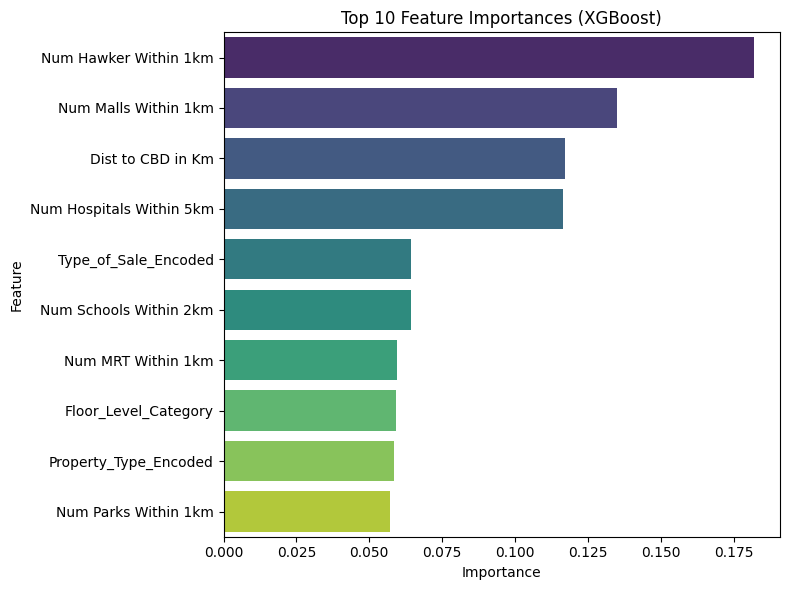


===== XGBoost Model Summary =====
R2: 0.7711
RMSE: 0.4810
MAE: 0.2797
MAPE: 279936.3358
CV_R2_mean: 0.2740
CV_R2_std: 0.1000
CV_RMSE_mean: 0.8563
CV_MAE_mean: 0.4907
CV_MAPE_mean: 289692.7349


In [41]:
# --- XGBoost Regression with CV and Scoring ---
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# --- Safe metrics ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Prepare Data ---
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# --- XGBoost Configuration ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=10000,
    learning_rate=0.2,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=3,
    reg_alpha=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Full-Sample Fit ---
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# --- Cross-Validation Metrics ---
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

# --- Aggregate CV Results ---
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# --- Feature Importance ---
import matplotlib.pyplot as plt
import seaborn as sns

importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\n===== Top Features by Importance =====")
print(feat_imp_df.head(10).to_string(index=False))

# --- Plot Feature Importances ---
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# --- Summary Output ---
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")



===== Full Sample Metrics =====
R2: 0.7711
RMSE: 0.4810
MAE: 0.2797
MAPE: 279936.3358
Fold 1 metrics: R2=0.3388, RMSE=0.7516, MAE=0.4876, MAPE=294935.4715
Fold 2 metrics: R2=0.0856, RMSE=1.1091, MAE=0.4951, MAPE=288014.8088
Fold 3 metrics: R2=0.3691, RMSE=0.7375, MAE=0.4867, MAPE=287585.9689
Fold 4 metrics: R2=0.2671, RMSE=0.8907, MAE=0.4936, MAPE=287715.0679
Fold 5 metrics: R2=0.3094, RMSE=0.7924, MAE=0.4904, MAPE=290212.3571

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.2740
CV_R2_std: 0.1000
CV_RMSE_mean: 0.8563
CV_MAE_mean: 0.4907
CV_MAPE_mean: 289692.7349

===== Full Feature Importance Ranking =====
                   Feature  Importance  Importance_Norm  Importance_Cum
     Num Hawker Within 1km    0.181807         0.181807        0.181807
      Num Malls Within 1km    0.134930         0.134930        0.316737
         Dist to CBD in Km    0.117001         0.117001        0.433738
  Num Hospitals Within 5km    0.116573         0.116573        0.550311
      Type_o

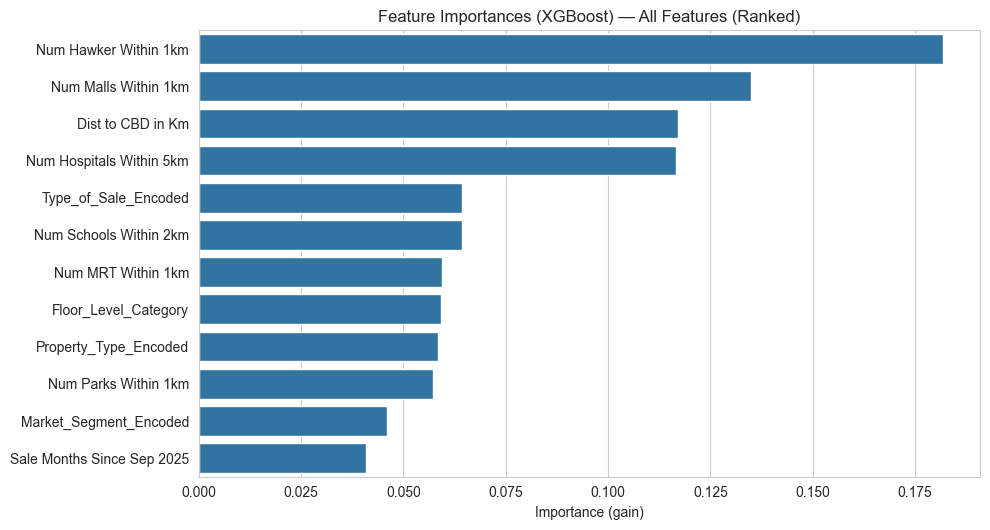

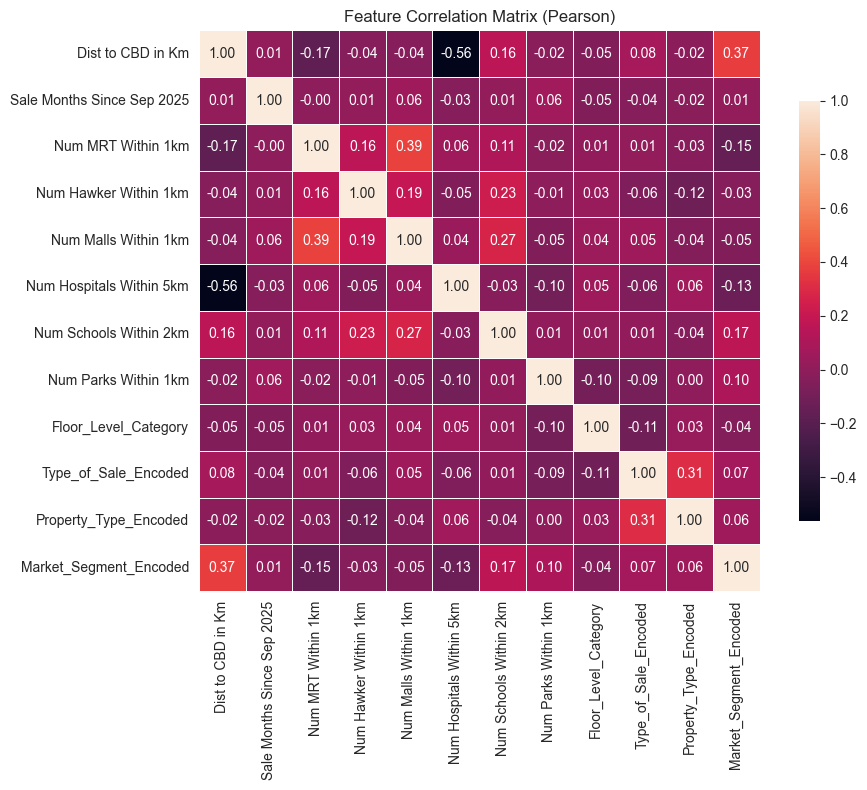

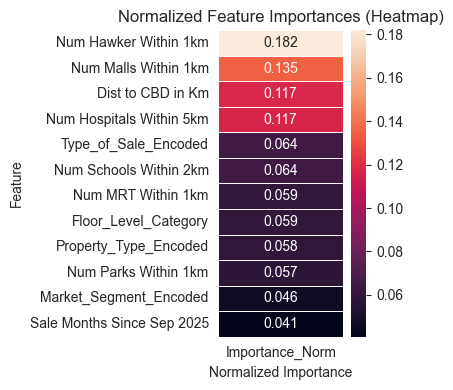


===== XGBoost Model Summary =====
R2: 0.7711
RMSE: 0.4810
MAE: 0.2797
MAPE: 279936.3358
CV_R2_mean: 0.2740
CV_R2_std: 0.1000
CV_RMSE_mean: 0.8563
CV_MAE_mean: 0.4907
CV_MAPE_mean: 289692.7349


In [7]:
# xgboost_with_full_feature_ranking_and_heatmaps.py
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
# keep only features present in df
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# --- Safe metrics ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Prepare Data ---
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# --- XGBoost Configuration ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=10000,
    learning_rate=0.2,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=3,
    reg_alpha=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

# --- Full-Sample Fit ---
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# --- Cross-Validation Metrics ---
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for fold_id, (train_idx, val_idx) in enumerate(kf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

    print(f"Fold {fold_id} metrics: R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, MAPE={m['MAPE']:.4f}")

# --- Aggregate CV Results ---
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# --- Feature Importance: full ranking, normalized, cumulative ---
importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

total_imp = feat_imp_df['Importance'].sum()
if total_imp <= 0:
    # guard: if all importances are zero (unlikely), set tiny eps to avoid div by zero
    total_imp = EPS

feat_imp_df['Importance_Norm'] = feat_imp_df['Importance'] / total_imp
feat_imp_df['Importance_Cum'] = feat_imp_df['Importance_Norm'].cumsum()

print("\n===== Full Feature Importance Ranking =====")
# show as table
print(feat_imp_df.to_string(index=False, float_format="{:.6f}".format))

# --- Plot: Bar chart of all feature importances (ranked) ---
plt.figure(figsize=(10, max(4, 0.45 * len(feature_cols))))
sns.set_style("whitegrid")
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', order=feat_imp_df['Feature'])
plt.title('Feature Importances (XGBoost) — All Features (Ranked)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.savefig("feature_importances_all_ranked.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot: Correlation heatmap of features (Pearson) ---
corr_mat = X.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title('Feature Correlation Matrix (Pearson)')
plt.tight_layout()
plt.savefig("feature_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot: Feature importance heatmap (normalized single column) ---
imp_heat = feat_imp_df[['Feature', 'Importance_Norm']].set_index('Feature')
plt.figure(figsize=(4, max(4, 0.25 * len(feature_cols))))
sns.heatmap(imp_heat, annot=True, fmt=".3f", cbar=True, linewidths=0.5)
plt.title('Normalized Feature Importances (Heatmap)')
plt.xlabel('Normalized Importance')
plt.tight_layout()
plt.savefig("feature_importance_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Optional: print summary ---
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")


## XGBoost with Feature Weightings

In [7]:
# XGBoost per-age-group models using feature weightings
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
selected_features = [
    'Dist to CBD in Km',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km'
]

# Confirm features exist
missing = [f for f in selected_features if f not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

# weights per age group (as provided)
weights = {
    'Young Adults': {
        'Dist to CBD in Km': 0.2376,
        'Num MRT Within 1km': 0.1338,
        'Num Hawker Within 1km': 0.1019,
        'Num Malls Within 1km': 0.1353,
        'Num Hospitals Within 5km': 0.0792,
        'Num Schools Within 2km': 0.2080,
        'Num Parks Within 1km': 0.0983
    },
    'Families': {
        'Dist to CBD in Km': 0.0709,
        'Num MRT Within 1km': 0.1819,
        'Num Hawker Within 1km': 0.1149,
        'Num Malls Within 1km': 0.2932,
        'Num Hospitals Within 5km': 0.1699,
        'Num Schools Within 2km': 0.0867,
        'Num Parks Within 1km': 0.0826
    },
    'Retirees': {
        'Dist to CBD in Km': 0.0420,
        'Num MRT Within 1km': 0.1658,
        'Num Hawker Within 1km': 0.2665,
        'Num Malls Within 1km': 0.0969,
        'Num Hospitals Within 5km': 0.1971,
        'Num Schools Within 2km': 0.0569,
        'Num Parks Within 1km': 0.1748
    }
}

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# --- Safe metrics ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Prepare Data ---
data = df[selected_features + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X_base = data[selected_features].astype(float).reset_index(drop=True)
y = data[target_col].astype(float).reset_index(drop=True)

# XGBoost params (same as your original)
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=10000,
    learning_rate=0.2,
    max_depth=10,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=3,
    reg_alpha=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Container for results
results = {}

# Loop through age groups: create weighted features, train model, evaluate
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for group_name, wmap in weights.items():
    # create weighted feature matrix: multiply each column by its group's weight
    w_vector = np.array([wmap[f] for f in selected_features], dtype=float)
    X_weighted = X_base.values * w_vector  # shape (n_samples, n_features)
    Xw_df = pd.DataFrame(X_weighted, columns=selected_features)

    # Full-sample fit
    model_full = XGBRegressor(**xgb_params)
    model_full.fit(Xw_df, y, verbose=False)
    y_pred_full = model_full.predict(Xw_df)
    full_metrics = compute_metrics(y, y_pred_full)

    # Cross-validation
    cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []
    for train_idx, val_idx in kf.split(Xw_df, y):
        X_train, X_val = Xw_df.iloc[train_idx], Xw_df.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model_cv = XGBRegressor(**xgb_params)
        model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        y_val_pred = model_cv.predict(X_val)
        m = compute_metrics(y_val, y_val_pred)
        cv_r2s.append(m['R2'])
        cv_rmses.append(m['RMSE'])
        cv_maes.append(m['MAE'])
        cv_mapes.append(m['MAPE'])

    cv_results = {
        'CV_R2_mean': np.mean(cv_r2s),
        'CV_R2_std': np.std(cv_r2s),
        'CV_RMSE_mean': np.mean(cv_rmses),
        'CV_MAE_mean': np.mean(cv_maes),
        'CV_MAPE_mean': np.mean(cv_mapes)
    }

    # Feature importances from full model (note: importances correspond to the weighted-feature magnitudes)
    importance = model_full.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': selected_features,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    # store everything
    results[group_name] = {
        'model': model_full,
        'full_metrics': full_metrics,
        'cv_results': cv_results,
        'feature_importances': feat_imp_df
    }

# --- Print summary for all groups ---
for group_name, info in results.items():
    print("\n" + "="*60)
    print(f"AGE GROUP: {group_name}")
    print("="*60)
    print("\nFull-sample metrics:")
    for k, v in info['full_metrics'].items():
        print(f"  {k}: {v:.4f}")
    print("\nCross-validation metrics (5-fold):")
    for k, v in info['cv_results'].items():
        print(f"  {k}: {v:.4f}")
    print("\nTop feature importances (from the group's model):")
    print(info['feature_importances'].head(10).to_string(index=False))



AGE GROUP: Young Adults

Full-sample metrics:
  R2: 0.4744
  RMSE: 0.7289
  MAE: 0.4947
  MAPE: 222640.4450

Cross-validation metrics (5-fold):
  CV_R2_mean: 0.3058
  CV_R2_std: 0.0754
  CV_RMSE_mean: 0.8370
  CV_MAE_mean: 0.5061
  CV_MAPE_mean: 223861.2341

Top feature importances (from the group's model):
                 Feature  Importance
   Num Hawker Within 1km    0.201232
    Num Malls Within 1km    0.171499
       Dist to CBD in Km    0.161409
Num Hospitals Within 5km    0.149934
      Num MRT Within 1km    0.117127
    Num Parks Within 1km    0.102243
  Num Schools Within 2km    0.096555

AGE GROUP: Families

Full-sample metrics:
  R2: 0.4744
  RMSE: 0.7289
  MAE: 0.4947
  MAPE: 222640.4450

Cross-validation metrics (5-fold):
  CV_R2_mean: 0.3058
  CV_R2_std: 0.0754
  CV_RMSE_mean: 0.8370
  CV_MAE_mean: 0.5061
  CV_MAPE_mean: 223861.2341

Top feature importances (from the group's model):
                 Feature  Importance
   Num Hawker Within 1km    0.201232
    Num Malls 

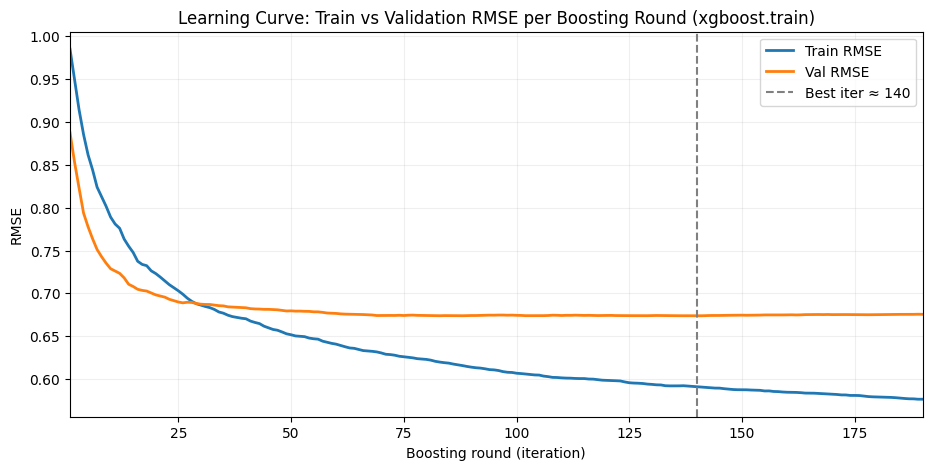

Recorded iterations: 190
Best iteration (0-based): 139
Best iteration (1-based): 140
Train RMSE final: 0.5766
Val RMSE final:   0.6756
Min Val RMSE:     0.6738 (at iter 140)


In [42]:
# Robust learning curve using xgboost.train + DMatrix (works across XGBoost versions)
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1) create train/validation split for learning curve
X_lc, X_val_lc, y_lc, y_val_lc = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# 2) convert to DMatrix (XGBoost's native format)
dtrain = xgb.DMatrix(X_lc, label=y_lc)
dval = xgb.DMatrix(X_val_lc, label=y_val_lc)
watchlist = [(dtrain, 'train'), (dval, 'validation')]

# 3) prepare params for xgb.train (translate from sklearn wrapper params)
train_params = xgb_params.copy()
# remove sklearn-only args if present
for k in ['n_estimators', 'random_state', 'n_jobs', 'verbosity']:
    train_params.pop(k, None)

# set/ensure eval metric and tree method
train_params['eval_metric'] = train_params.get('eval_metric', 'rmse')
train_params['tree_method'] = train_params.get('tree_method', 'hist')  # use 'gpu_hist' on GPU if available

# 4) set number of boosting rounds and early stopping rounds
num_boost_round = 5000
early_stopping_rounds = 50

# 5) container for eval results
evals_result = {}

# 6) call xgboost.train (this supports early_stopping_rounds and returns history)
bst = xgb.train(
    params=train_params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    early_stopping_rounds=early_stopping_rounds,
    evals_result=evals_result,
    verbose_eval=False
)

# 7) extract RMSE history
# keys typically: evals_result['train']['rmse'] and evals_result['validation']['rmse']
train_rmse = np.array(evals_result['train']['rmse'], dtype=float)
val_rmse   = np.array(evals_result['validation']['rmse'], dtype=float)
n_iters = len(train_rmse)
iters = np.arange(1, n_iters + 1)

# 8) best iteration from booster
best_iter = getattr(bst, "best_iteration", None)
if best_iter is None:
    # fallback: minimal val rmse index
    best_iter = int(np.argmin(val_rmse))
# convert to 1-based index for plotting clarity
best_iter_plot = best_iter + 1

# 9) Plot learning curve
plt.figure(figsize=(11,5))
plt.plot(iters, train_rmse, label='Train RMSE', linewidth=2)
plt.plot(iters, val_rmse, label='Val RMSE', linewidth=2)
plt.axvline(x=best_iter_plot, color='gray', linestyle='--', label=f'Best iter ≈ {best_iter_plot}')
plt.xlim(1, max(50, n_iters))
plt.xlabel('Boosting round (iteration)')
plt.ylabel('RMSE')
plt.title('Learning Curve: Train vs Validation RMSE per Boosting Round (xgboost.train)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 10) print concise stats
print(f"Recorded iterations: {n_iters}")
print(f"Best iteration (0-based): {best_iter}")
print(f"Best iteration (1-based): {best_iter_plot}")
print(f"Train RMSE final: {train_rmse[-1]:.4f}")
print(f"Val RMSE final:   {val_rmse[-1]:.4f}")
print(f"Min Val RMSE:     {val_rmse.min():.4f} (at iter {int(np.argmin(val_rmse))+1})")


Running XGBoost model for 27 districts...


District 1 (n=1638) — training model...
  → R² = 0.747, CV R² = 0.104
  Top 3 features: ['Property_Type_Encoded', 'Num Hawker Within 1km', 'Dist to CBD in Km']

District 2 (n=1207) — training model...
  → R² = 0.970, CV R² = 0.412
  Top 3 features: ['Num MRT Within 1km', 'Floor_Level_Category', 'Sale Months Since Sep 2025']

District 3 (n=4625) — training model...
  → R² = 0.660, CV R² = 0.448
  Top 3 features: ['Num Hawker Within 1km', 'Num Hospitals Within 5km', 'Dist to CBD in Km']

District 4 (n=2112) — training model...
  → R² = 0.798, CV R² = 0.436
  Top 3 features: ['Num Hawker Within 1km', 'Num Parks Within 1km', 'Num Hospitals Within 5km']

District 5 (n=7943) — training model...
  → R² = 0.599, CV R² = 0.448
  Top 3 features: ['Num MRT Within 1km', 'Type_of_Sale_Encoded', 'Property_Type_Encoded']

District 6 (n=705) — training model...
  → R² = 0.506, CV R² = 0.069
  Top 3 features: ['Num MRT Within 1km', 'Num Hawker Within 1km', 'N

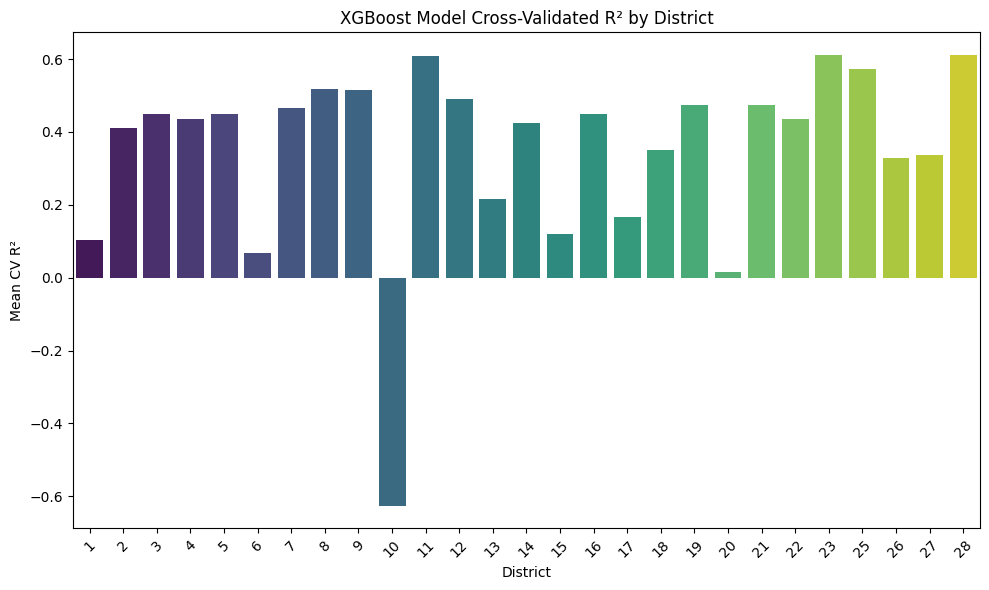

In [ ]:
# --- XGBoost Regression per District ---
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
district_col = 'District'

# Features to use
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
feature_cols = [f for f in feature_cols if f in df.columns]

MIN_ROWS_PER_DISTRICT = 100
CV_FOLDS = 5
RANDOM_STATE = 42
EPS = 1e-6

# --- XGBoost Parameters ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Helpers ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Containers ---
district_metrics = []  # for RMSE, R2, etc.
district_importances = []  # for feature importance

districts = sorted(df[district_col].dropna().unique())

print(f"Running XGBoost model for {len(districts)} districts...\n")

# --- Loop over districts ---
for dist in districts:
    df_dist = df[df[district_col] == dist].dropna(subset=[target_col] + feature_cols).copy()
    n = len(df_dist)
    if n < MIN_ROWS_PER_DISTRICT:
        print(f"Skipping District {dist} — only {n} samples (< {MIN_ROWS_PER_DISTRICT})")
        continue

    print(f"\nDistrict {dist} (n={n}) — training model...")

    X = df_dist[feature_cols].astype(float)
    y = df_dist[target_col].astype(float)

    # --- Full Sample Fit ---
    model_full = XGBRegressor(**xgb_params)
    model_full.fit(X, y)
    y_pred_full = model_full.predict(X)
    full_metrics = compute_metrics(y, y_pred_full)

    # --- Cross-Validation ---
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

    for tr_idx, val_idx in kf.split(X, y):
        X_train, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model_cv = XGBRegressor(**xgb_params)
        model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        y_val_pred = model_cv.predict(X_val)
        m = compute_metrics(y_val, y_val_pred)

        cv_r2s.append(m['R2'])
        cv_rmses.append(m['RMSE'])
        cv_maes.append(m['MAE'])
        cv_mapes.append(m['MAPE'])

    cv_results = {
        'District': dist,
        'n': n,
        'R2_full': full_metrics['R2'],
        'RMSE_full': full_metrics['RMSE'],
        'MAE_full': full_metrics['MAE'],
        'MAPE_full': full_metrics['MAPE'],
        'CV_R2_mean': np.mean(cv_r2s),
        'CV_R2_std': np.std(cv_r2s),
        'CV_RMSE_mean': np.mean(cv_rmses),
        'CV_MAE_mean': np.mean(cv_maes),
        'CV_MAPE_mean': np.mean(cv_mapes)
    }
    district_metrics.append(cv_results)

    # --- Feature Importance ---
    imp = model_full.feature_importances_
    imp_df = pd.DataFrame({
        'District': dist,
        'Feature': feature_cols,
        'Importance': imp
    }).sort_values('Importance', ascending=False)
    district_importances.append(imp_df)

    print(f"  → R² = {full_metrics['R2']:.3f}, CV R² = {cv_results['CV_R2_mean']:.3f}")
    print(f"  Top 3 features: {imp_df.head(3)['Feature'].tolist()}")

# --- Combine all results ---
metrics_df = pd.DataFrame(district_metrics)
importances_df = pd.concat(district_importances, ignore_index=True)

# --- Save outputs ---
metrics_df.to_csv("xgb_district_metrics.csv", index=False)
importances_df.to_csv("xgb_district_feature_importances.csv", index=False)
print("\nSaved 'xgb_district_metrics.csv' and 'xgb_district_feature_importances.csv'.")

# --- Summary of Top Features per District ---
top_features = (
    importances_df.sort_values(['District','Importance'], ascending=[True, False])
    .groupby('District')
    .first()
    .reset_index()[['District','Feature','Importance']]
)
top_features = top_features.merge(
    metrics_df[['District','CV_R2_mean','CV_RMSE_mean','n']],
    on='District', how='left'
).sort_values('CV_R2_mean', ascending=False)

print("\n===== Top Feature per District (Ranked by CV R²) =====")
print(top_features.head(10).to_string(index=False))

# --- Optional Visualization ---
plt.figure(figsize=(10,6))
sns.barplot(data=metrics_df.sort_values('CV_R2_mean', ascending=False),
            x='District', y='CV_R2_mean', palette='viridis')
plt.title("XGBoost Model Cross-Validated R² by District")
plt.ylabel("Mean CV R²")
plt.xlabel("District")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


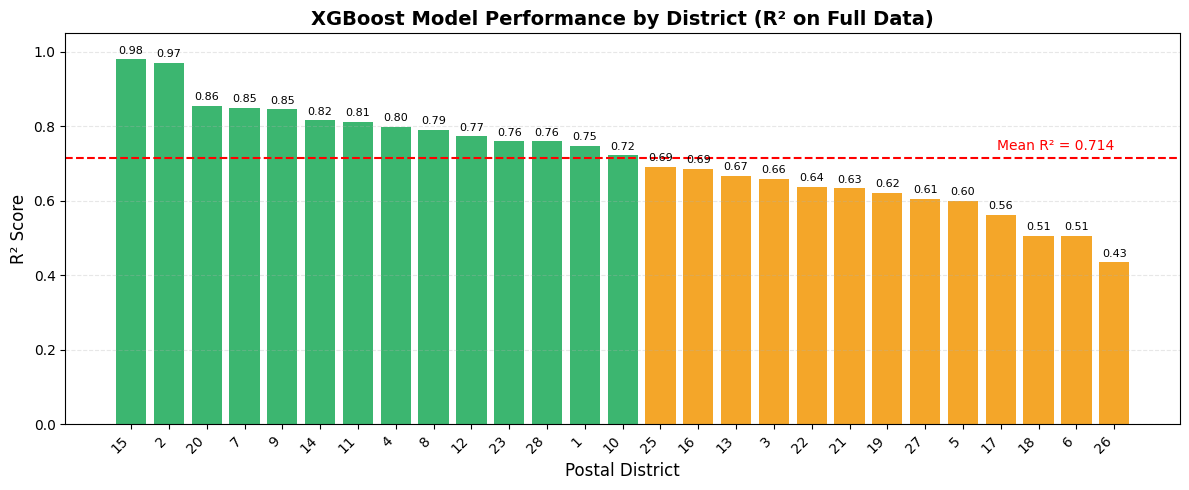

In [11]:
# --- Visualization: District Ranking by Actual R² (Full Sample) ---

# Sort districts by R² descending
metrics_sorted = metrics_df.sort_values("R2_full", ascending=False).reset_index(drop=True)

# Calculate mean R²
mean_r2 = metrics_sorted["R2_full"].mean()

# Define colors: green if above mean, orange if below
colors = [
    "#27ae60" if r2 >= mean_r2 else "#f39c12"
    for r2 in metrics_sorted["R2_full"]
]

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(
    metrics_sorted["District"].astype(str),
    metrics_sorted["R2_full"],
    color=colors,
    alpha=0.9
)

# Add mean R² reference line
plt.axhline(mean_r2, color="red", linestyle="--", linewidth=1.5)
plt.text(
    len(metrics_sorted) - 1, mean_r2 + 0.015,
    f"Mean R² = {mean_r2:.3f}",
    color="red", fontsize=10, ha="right", va="bottom"
)

# Add text labels on top of bars (optional)
for i, (dist, r2) in enumerate(zip(metrics_sorted["District"], metrics_sorted["R2_full"])):
    plt.text(i, r2 + 0.01, f"{r2:.2f}", ha="center", va="bottom", fontsize=8, color="black")

# Customize chart
plt.title("XGBoost Model Performance by District (R² on Full Data)", fontsize=14, fontweight="bold")
plt.xlabel("Postal District", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("xgb_r2_full_performance_by_district.png", dpi=300)
plt.show()


In [ ]:
pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.6 MB 7.2 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.6 MB 5.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/12.6 MB 5.1 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.6 MB 5.1 MB/s eta 0:00:02
   ---------------- ----------------------- 5.2/12.6 MB 5.2 MB/s eta 0:00:02
   ------------------- -------------------- 6.3/12.6 MB 5.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.6 MB 5.2 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.6 MB 5.3 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------- ----- 11.0/12.6 MB 5.3 MB/s eta 0:00:01
   -------------------------

  You can safely remove it manually.
  You can safely remove it manually.


## LightGBM

Using 108372 rows and 12 features for the overall LightGBM model.

--- Full-sample metrics (training data) ---
R² = 0.3899, RMSE = 0.79, MAE = 0.49, MAPE = 177144.1461

--- Cross-validated metrics (5-fold) ---
R² mean ± std = 0.3588 ± 0.0576
RMSE mean ± std = 0.80 ± 0.11
MAE mean ± std = 0.50 ± 0.00
MAPE mean ± std = 177830.0738 ± 1218.0736

Top 10 features by average gain importance:
                   Feature  Avg_Importance_Gain  Raw_Avg_Gain
Sale Months Since Sep 2025             0.200512  1.258705e+06
      Type_of_Sale_Encoded             0.198984  1.249117e+06
         Dist to CBD in Km             0.084545  5.307305e+05
      Num Malls Within 1km             0.076884  4.826370e+05
     Property_Type_Encoded             0.076713  4.815631e+05
      Num Parks Within 1km             0.062271  3.909048e+05
    Num Schools Within 2km             0.061706  3.873561e+05
  Num Hospitals Within 5km             0.055350  3.474594e+05
        Num MRT Within 1km             0.051021  3.202

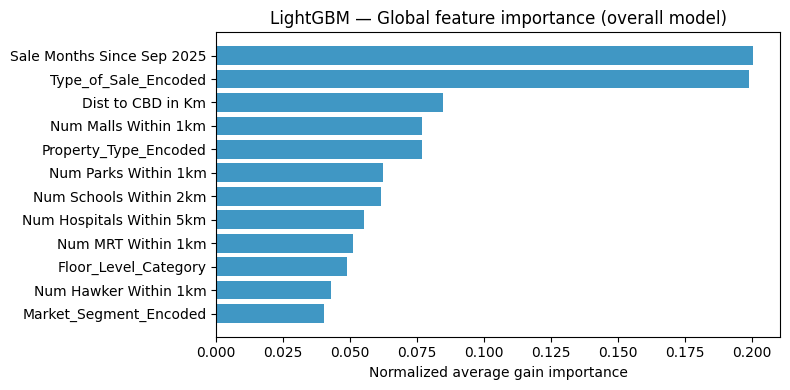

In [49]:
# LightGBM overall model with full-sample + CV metrics and feature importances
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

# ----------------- CONFIG -----------------
df_work = df.copy()   # your DataFrame (already in workspace)
target_col = 'Transacted Price ($)'

feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# Keep only features found in df
feature_cols = [c for c in feature_cols if c in df_work.columns]
if len(feature_cols) == 0:
    raise ValueError("No feature columns found in df. Check feature_cols list.")

# Model / CV settings
N_FOLDS = 5
SEED = 42
MIN_ROWS = 50  # require at least this many rows to run model

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'dart',
    'learning_rate': 0.01,
    'num_leaves': 70,
    'min_data_in_leaf': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 2,
    'lambda_l2': 5,
    'seed': SEED
}

# ----------------- PREPARE DATA -----------------
data = df_work[feature_cols + [target_col]].dropna().reset_index(drop=True)
n_rows = len(data)
print(f"Using {n_rows} rows and {len(feature_cols)} features for the overall LightGBM model.")

if n_rows < MIN_ROWS:
    raise ValueError(f"Insufficient rows ({n_rows}) after dropna. Need >= {MIN_ROWS} rows.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float).values

# safe MAPE (avoid division by zero)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    return mean_absolute_percentage_error(y_true, y_pred)

# ----------------- FULL-SAMPLE FIT (for reference) -----------------
dtrain_full = lgb.Dataset(X, label=y)
model_full = lgb.train(
    params=lgb_params,
    train_set=dtrain_full,
    num_boost_round=2000,
    valid_sets=[dtrain_full],
    callbacks=[lgb.log_evaluation(period=0)]
)
y_full_pred = model_full.predict(X, num_iteration=model_full.best_iteration)
full_r2 = r2_score(y, y_full_pred)
full_rmse = mean_squared_error(y, y_full_pred, squared=False)
full_mae = mean_absolute_error(y, y_full_pred)
full_mape = safe_mape(y, y_full_pred)

print("\n--- Full-sample metrics (training data) ---")
print(f"R² = {full_r2:.4f}, RMSE = {full_rmse:.2f}, MAE = {full_mae:.2f}, MAPE = {full_mape:.4f}")

# ----------------- K-FOLD CV -----------------
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

r2_folds = []
rmse_folds = []
mae_folds = []
mape_folds = []
fold_importances = pd.DataFrame(0, index=feature_cols, columns=range(N_FOLDS))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

    # callbacks for early stopping
    callbacks = [
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=0)
    ]

    model = lgb.train(
        params=lgb_params,
        train_set=lgb_train,
        num_boost_round=2000,
        valid_sets=[lgb_train, lgb_val],
        callbacks=callbacks
    )

    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    r2_folds.append(r2_score(y_val, y_pred))
    rmse_folds.append(mean_squared_error(y_val, y_pred, squared=False))
    mae_folds.append(mean_absolute_error(y_val, y_pred))
    mape_folds.append(safe_mape(y_val, y_pred))

    # store gain importances
    imp = model.feature_importance(importance_type='gain')
    fold_importances[fold] = pd.Series(imp, index=feature_cols)

# CV aggregates
cv_r2_mean, cv_r2_std = np.mean(r2_folds), np.std(r2_folds)
cv_rmse_mean, cv_rmse_std = np.mean(rmse_folds), np.std(rmse_folds)
cv_mae_mean, cv_mae_std = np.mean(mae_folds), np.std(mae_folds)
cv_mape_mean, cv_mape_std = np.mean(mape_folds), np.std(mape_folds)

print("\n--- Cross-validated metrics ({}-fold) ---".format(N_FOLDS))
print(f"R² mean ± std = {cv_r2_mean:.4f} ± {cv_r2_std:.4f}")
print(f"RMSE mean ± std = {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}")
print(f"MAE mean ± std = {cv_mae_mean:.2f} ± {cv_mae_std:.2f}")
print(f"MAPE mean ± std = {cv_mape_mean:.4f} ± {cv_mape_std:.4f}")

# ----------------- FEATURE IMPORTANCE (avg gain, normalized) -----------------
avg_imp = fold_importances.mean(axis=1)
if avg_imp.sum() > 0:
    avg_imp_norm = avg_imp / avg_imp.sum()
else:
    avg_imp_norm = avg_imp

imp_df = pd.DataFrame({
    'Feature': avg_imp_norm.index,
    'Avg_Importance_Gain': avg_imp_norm.values,
    'Raw_Avg_Gain': avg_imp.values
}).reset_index(drop=True).sort_values('Avg_Importance_Gain', ascending=False)

print("\nTop 10 features by average gain importance:")
print(imp_df.head(10).to_string(index=False))

# ----------------- SAVE OUTPUTS -----------------
imp_df.to_csv("lgb_overall_feature_importances.csv", index=False)

cv_summary = {
    'metric': ['r2','rmse','mae','mape'],
    'full_sample': [full_r2, full_rmse, full_mae, full_mape],
    'cv_mean': [cv_r2_mean, cv_rmse_mean, cv_mae_mean, cv_mape_mean],
    'cv_std': [cv_r2_std, cv_rmse_std, cv_mae_std, cv_mape_std]
}
cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df.to_csv("lgb_overall_cv_summary.csv", index=False)

print("\nSaved 'lgb_overall_feature_importances.csv' and 'lgb_overall_cv_summary.csv'.")

# ----------------- OPTIONAL: quick plot (bar) -----------------
import matplotlib.pyplot as plt
plt.figure(figsize=(8, max(4, 0.25 * len(imp_df))))
plt.barh(imp_df['Feature'][::-1], imp_df['Avg_Importance_Gain'][::-1], color='#2b8cbe', alpha=0.9)
plt.xlabel('Normalized average gain importance')
plt.title('LightGBM — Global feature importance (overall model)')
plt.tight_layout()
plt.show()


## Catboost

In [ ]:
pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 2.8 MB/s eta 0:00:37
    --------------------------------------- 1.8/102.4 MB 4.8 MB/s eta 0:00:21
   - -------------------------------------- 3.1/102.4 MB 5.4 MB/s eta 0:00:19
   - -------------------------------------- 4.2/102.4 MB 5.3 MB/s eta 0:00:19
   -- ------------------------------------- 5.5/102.4 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/102.4 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 8.4/102.4 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 9.2/102.4 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 10.7/102.4 MB 5.7 MB/s eta 0:00:16
   ---- ----------------------------------- 12.1/102.4 MB 5.8 MB/s eta 0:00:16
   ----- ---------------------------------- 13.4/102.4 MB 5.9 MB/s eta 0:00:16
   ----- ---------------------------------- 14.4/102.4 MB 5.8 MB/s e

In [16]:
# CatBoost overall (whole-dataset) with full CV metrics + averaged feature importances
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor, Pool
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
df_work = df.copy()  # your dataframe already loaded in the notebook
target_col = 'Transacted Price ($)'

feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'Area (SQFT)'
]
# keep only existing features
feature_cols = [c for c in feature_cols if c in df_work.columns]

# CV & model params
N_FOLDS = 5
SEED = 42
MIN_ROWS = 50  # require minimal rows to run overall model

cat_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'random_seed': SEED,
    'logging_level': 'Silent',
    'early_stopping_rounds': 50
}

# --- sanity checks ---
if df_work.shape[0] < MIN_ROWS:
    raise ValueError(f"Not enough rows ({df_work.shape[0]}) to run the overall model (min {MIN_ROWS}).")

data = df_work[feature_cols + [target_col]].dropna().reset_index(drop=True)
if data.shape[0] < MIN_ROWS:
    raise ValueError(f"Not enough non-null rows after dropna ({data.shape[0]}).")

X = data[feature_cols].reset_index(drop=True)
y = data[target_col].astype(float).values

# Helper safe MAPE (avoid division by zero)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    return mean_absolute_percentage_error(y_true, y_pred)

# Containers for fold metrics & importances
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
rmse_folds = []
r2_folds = []
mae_folds = []
mape_folds = []
fold_importances = pd.DataFrame(0, index=feature_cols, columns=range(N_FOLDS))

print(f"Running {N_FOLDS}-fold CV on overall data (n = {len(y)}) with CatBoost...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)

    model = CatBoostRegressor(**cat_params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    y_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mape = safe_mape(y_val, y_pred)

    rmse_folds.append(rmse)
    r2_folds.append(r2)
    mae_folds.append(mae)
    mape_folds.append(mape)

    # Feature importance (gain based on training pool)
    imp = model.get_feature_importance(train_pool)  # returns array aligned with feature_cols
    fold_importances[fold] = pd.Series(imp, index=feature_cols)

    print(f" Fold {fold+1}/{N_FOLDS}: RMSE={rmse:.2f}, R2={r2:.3f}, MAE={mae:.2f}, MAPE={mape:.4f}")

# Aggregate CV metrics
metrics_summary = {
    'RMSE_mean': np.mean(rmse_folds),
    'RMSE_std': np.std(rmse_folds),
    'R2_mean': np.mean(r2_folds),
    'R2_std': np.std(r2_folds),
    'MAE_mean': np.mean(mae_folds),
    'MAE_std': np.std(mae_folds),
    'MAPE_mean': np.mean(mape_folds),
    'MAPE_std': np.std(mape_folds),
    'n': len(y)
}

print("\n=== Cross-Validation Summary ===")
for k, v in metrics_summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Average & normalize importances across folds
avg_imp = fold_importances.mean(axis=1)
avg_imp_norm = avg_imp / avg_imp.sum() if avg_imp.sum() > 0 else avg_imp

imp_df = (
    pd.DataFrame({
        'Feature': avg_imp_norm.index,
        'Avg_Importance': avg_imp_norm.values,
        'Raw_Avg_Importance': avg_imp.values
    })
    .sort_values('Avg_Importance', ascending=False)
    .reset_index(drop=True)
)

# Save outputs
imp_df.to_csv("catboost_feature_importances_overall.csv", index=False)
pd.DataFrame([metrics_summary]).to_csv("catboost_cv_metrics_overall.csv", index=False)

# Print top features
print("\nTop 10 features by averaged importance (CatBoost):")
for i, r in imp_df.head(10).iterrows():
    print(f"  {i+1}. {r['Feature']}: {r['Avg_Importance']:.4f} (raw {r['Raw_Avg_Importance']:.2f})")

# Optional: train final model on full dataset (use best params & iterations from CV folds average)
final_pool = Pool(X, y)
final_model = CatBoostRegressor(**cat_params)
final_model.fit(final_pool, use_best_model=True)

# Save final model feature importance too
final_imp = final_model.get_feature_importance(final_pool)
final_imp_df = pd.DataFrame({'Feature': feature_cols, 'Final_Importance': final_imp}).sort_values('Final_Importance', ascending=False)
final_imp_df.to_csv("catboost_feature_importances_overall_final_model.csv", index=False)

print("\nSaved:")
print(" - catboost_feature_importances_overall.csv")
print(" - catboost_cv_metrics_overall.csv")
print(" - catboost_feature_importances_overall_final_model.csv")

# Short interpretation stub
print("\nQuick interpretation tips:")
print(" - Higher Avg_Importance means the feature contributes more (according to CatBoost) to predicting price.")
print(" - Use CV R2 and RMSE to judge predictive quality; also inspect MAE and MAPE for robust error measures.")


Running 5-fold CV on overall data (n = 108372) with CatBoost...
 Fold 1/5: RMSE=0.34, R2=0.861, MAE=0.20, MAPE=306995.5343
 Fold 2/5: RMSE=0.67, R2=0.667, MAE=0.12, MAPE=323031.6755
 Fold 3/5: RMSE=0.25, R2=0.927, MAE=0.11, MAPE=318071.4315
 Fold 4/5: RMSE=0.50, R2=0.768, MAE=0.12, MAPE=321165.5135
 Fold 5/5: RMSE=0.31, R2=0.896, MAE=0.12, MAPE=321491.6637

=== Cross-Validation Summary ===
  RMSE_mean: 0.4148
  RMSE_std: 0.1522
  R2_mean: 0.8237
  R2_std: 0.0950
  MAE_mean: 0.1316
  MAE_std: 0.0318
  MAPE_mean: 318151.1637
  MAPE_std: 5805.4985
  n: 108372

Top 10 features by averaged importance (CatBoost):
  1. Area (SQFT): 0.4283 (raw 42.83)
  2. Type_of_Sale_Encoded: 0.1959 (raw 19.59)
  3. Sale Months Since Sep 2025: 0.0924 (raw 9.24)
  4. Dist to CBD in Km: 0.0413 (raw 4.13)
  5. Market_Segment_Encoded: 0.0386 (raw 3.86)
  6. Property_Type_Encoded: 0.0353 (raw 3.53)
  7. Num MRT Within 1km: 0.0274 (raw 2.74)
  8. Num Hospitals Within 5km: 0.0262 (raw 2.62)
  9. Num Parks Within 1k

You should provide test set for use best model. use_best_model parameter has been switched to false value.



Saved:
 - catboost_feature_importances_overall.csv
 - catboost_cv_metrics_overall.csv
 - catboost_feature_importances_overall_final_model.csv

Quick interpretation tips:
 - Higher Avg_Importance means the feature contributes more (according to CatBoost) to predicting price.
 - Use CV R2 and RMSE to judge predictive quality; also inspect MAE and MAPE for robust error measures.


In [ ]:
# --- CatBoost per-district feature importance + full CV metrics pipeline ----------
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor, Pool
import warnings
warnings.filterwarnings("ignore")

# ---- Config ----
target_col = 'Transacted Price ($)'
district_col = 'District'

# Feature list (same as LGBM pipeline)
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
# keep only features that exist
feature_cols = [c for c in feature_cols if c in df.columns]

MIN_ROWS_PER_DISTRICT = 100
N_FOLDS = 5
SEED = 42

# CatBoost Parameters
cat_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'random_seed': SEED,
    'logging_level': 'Silent',
    'early_stopping_rounds': 50
}

# Containers for results
district_importances = []
district_cv_scores = []

# Helper: safe MAPE (avoid division by zero)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    return mean_absolute_percentage_error(y_true, y_pred)

# Loop through each district
districts = sorted(df[district_col].dropna().unique())

for dist in districts:
    df_dist = df[df[district_col] == dist].copy()
    n = len(df_dist)
    if n < MIN_ROWS_PER_DISTRICT:
        print(f"Skipping District {dist} — only {n} rows (< {MIN_ROWS_PER_DISTRICT})")
        continue

    print(f"\nTraining CatBoost for District {dist} (n={n})")

    # Drop missing values in selected columns
    data = df_dist[feature_cols + [target_col]].dropna()
    if data.shape[0] < MIN_ROWS_PER_DISTRICT:
        print(f"  After dropna: skip (insufficient rows: {data.shape[0]})")
        continue

    X = data[feature_cols].reset_index(drop=True)
    y = data[target_col].astype(float).values

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    # per-fold metrics lists
    rmse_folds = []
    r2_folds = []
    mae_folds = []
    mape_folds = []
    fold_importances = pd.DataFrame(0, index=feature_cols, columns=range(N_FOLDS))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Pools
        train_pool = Pool(X_train, y_train)
        val_pool = Pool(X_val, y_val)

        model = CatBoostRegressor(**cat_params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)

        y_pred = model.predict(X_val)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        r2 = r2_score(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        mape = safe_mape(y_val, y_pred)

        rmse_folds.append(rmse)
        r2_folds.append(r2)
        mae_folds.append(mae)
        mape_folds.append(mape)

        # Feature importance (gain) for this fold
        imp = model.get_feature_importance(train_pool)  # training-based importances
        fold_importances[fold] = pd.Series(imp, index=feature_cols)

    # Aggregate importances & normalize
    avg_imp = fold_importances.mean(axis=1)
    avg_imp_norm = avg_imp / avg_imp.sum() if avg_imp.sum() > 0 else avg_imp

    imp_df = (
        pd.DataFrame({
            'District': dist,
            'Feature': avg_imp_norm.index,
            'Avg_Importance': avg_imp_norm.values,
            'Raw_Importance': avg_imp.values
        })
        .sort_values('Avg_Importance', ascending=False)
        .reset_index(drop=True)
    )

    # CV metric summaries (mean, std)
    rmse_mean, rmse_std = (np.mean(rmse_folds), np.std(rmse_folds)) if rmse_folds else (np.nan, np.nan)
    r2_mean, r2_std = (np.mean(r2_folds), np.std(r2_folds)) if r2_folds else (np.nan, np.nan)
    mae_mean, mae_std = (np.mean(mae_folds), np.std(mae_folds)) if mae_folds else (np.nan, np.nan)
    mape_mean, mape_std = (np.mean(mape_folds), np.std(mape_folds)) if mape_folds else (np.nan, np.nan)

    # Save district summary
    district_importances.append({
        'District': dist,
        'n': n,
        'rmse_mean': rmse_mean,
        'rmse_std': rmse_std,
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'mae_mean': mae_mean,
        'mae_std': mae_std,
        'mape_mean': mape_mean,
        'mape_std': mape_std,
        'imp_df': imp_df
    })

    district_cv_scores.append({
        'District': dist,
        'n': n,
        'RMSE_mean': rmse_mean,
        'RMSE_std': rmse_std,
        'R2_mean': r2_mean,
        'R2_std': r2_std,
        'MAE_mean': mae_mean,
        'MAE_std': mae_std,
        'MAPE_mean': mape_mean,
        'MAPE_std': mape_std
    })

    # Display top 5 important features
    print(f"  CV RMSE mean={rmse_mean:.2f}, CV R² mean={r2_mean:.3f}")
    print("  Top 5 features:")
    for i, row in imp_df.head(5).iterrows():
        print(f"   - {row['Feature']}: {row['Avg_Importance']:.3f}")

# --- Consolidate all feature importances & CV scores to CSVs ---
rows = []
for rec in district_importances:
    imp_df = rec['imp_df']
    for _, r in imp_df.iterrows():
        rows.append({
            'District': rec['District'],
            'n': rec['n'],
            'Feature': r['Feature'],
            'Avg_Importance': r['Avg_Importance'],
            'Raw_Importance': r['Raw_Importance'],
            'RMSE_mean': rec['rmse_mean'],
            'RMSE_std': rec['rmse_std'],
            'R2_mean': rec['r2_mean'],
            'R2_std': rec['r2_std'],
            'MAE_mean': rec['mae_mean'],
            'MAE_std': rec['mae_std'],
            'MAPE_mean': rec['mape_mean'],
            'MAPE_std': rec['mape_std']
        })

feat_importances_all = pd.DataFrame(rows)
feat_importances_all.to_csv("catboost_feature_importances_by_district.csv", index=False)

cv_scores_df = pd.DataFrame(district_cv_scores)
cv_scores_df.to_csv("catboost_cv_scores_by_district.csv", index=False)

print("\nSaved 'catboost_feature_importances_by_district.csv' and 'catboost_cv_scores_by_district.csv'.")

# --- Quick summary: Top feature by district ---
top_features = (
    feat_importances_all.sort_values(['District', 'Avg_Importance'], ascending=[True, False])
    .groupby('District')
    .first()
    .reset_index()[['District', 'Feature', 'Avg_Importance', 'n', 'RMSE_mean', 'R2_mean']]
    .sort_values('Avg_Importance', ascending=False)
)
print("\nTop feature by district (sample):")
print(top_features.head(10))



Training CatBoost for District 1 (n=1638)
  CV RMSE mean=0.24, CV R² mean=0.937
  Top 5 features:
   - Area (SQFT): 0.769
   - Num MRT Within 1km: 0.047
   - Num Hawker Within 1km: 0.028
   - Num Hospitals Within 5km: 0.023
   - Num Parks Within 1km: 0.021

Training CatBoost for District 2 (n=1207)


KeyboardInterrupt: 

In [21]:
pip install shap

   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   --------------------------------------- 548.0/548.0 kB 17.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Data: 108372 rows, 13 features
Using existing 'final_model' from workspace.
Using sample_frac=0.3 -> 32512 rows for SHAP calculation.
SHAP values shape: (32512, 13)
Saved SHAP ranking to catboost_shap_overall_mean_abs_shap_ranking.csv


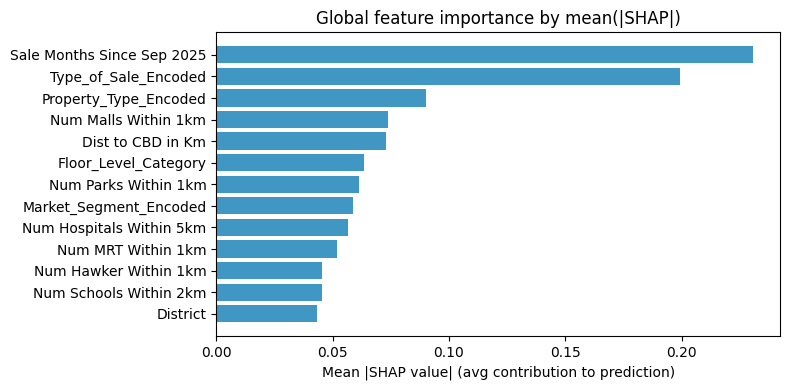

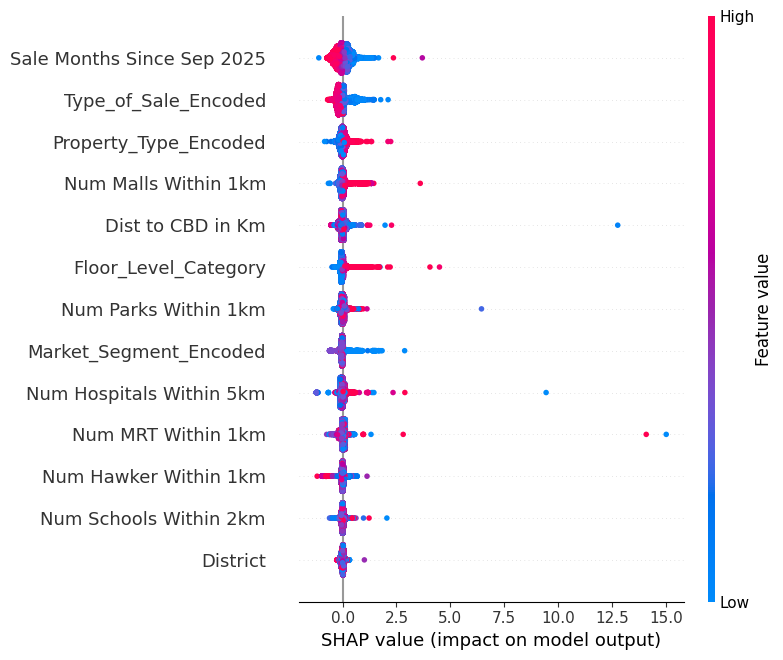

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

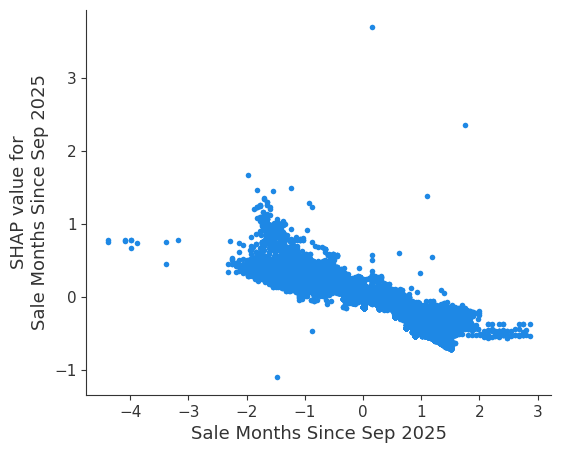

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

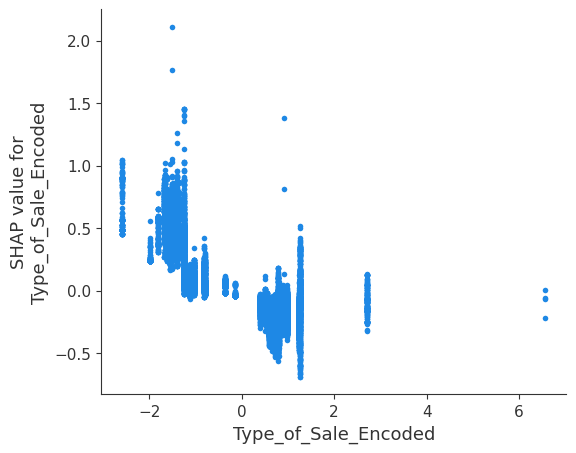

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

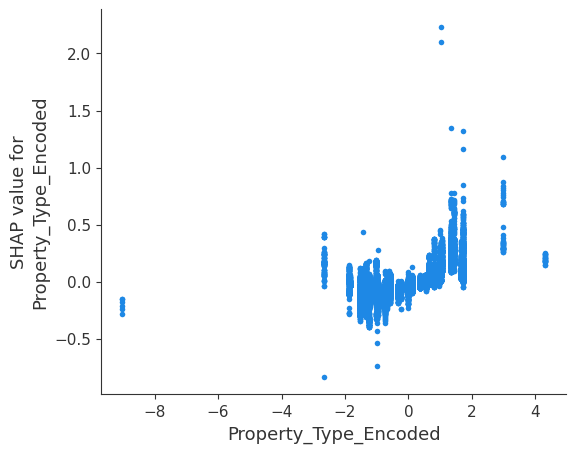

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

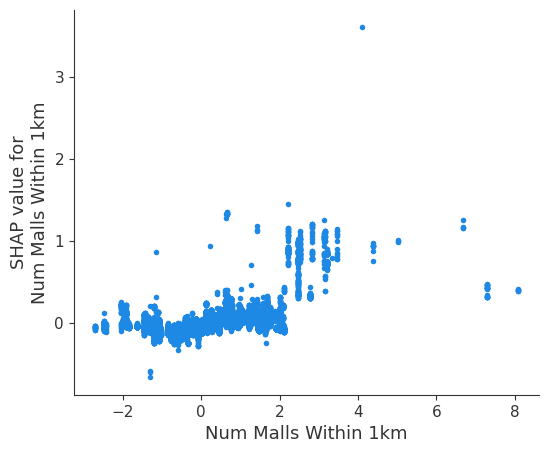

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

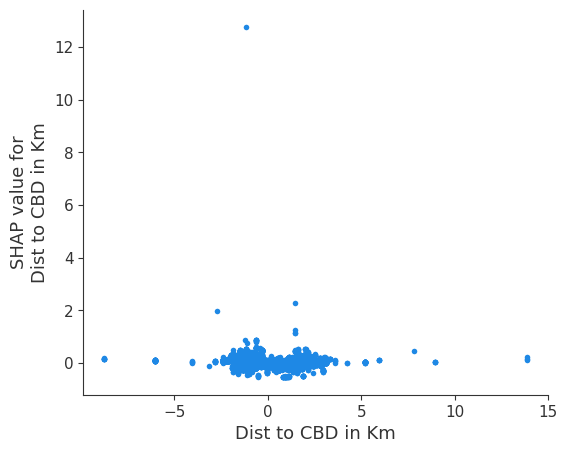

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

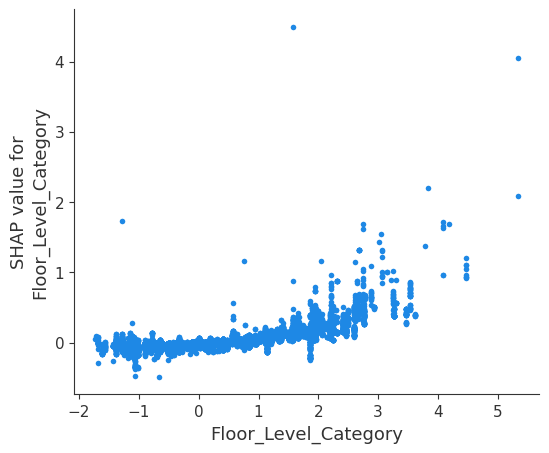


Top features by mean(|SHAP|):
                   Feature  MeanAbsSHAP  Share
Sale Months Since Sep 2025       0.2307 0.2111
      Type_of_Sale_Encoded       0.1992 0.1823
     Property_Type_Encoded       0.0902 0.0825
      Num Malls Within 1km       0.0739 0.0676
         Dist to CBD in Km       0.0731 0.0669
      Floor_Level_Category       0.0635 0.0581
      Num Parks Within 1km       0.0612 0.0560
    Market_Segment_Encoded       0.0586 0.0536
  Num Hospitals Within 5km       0.0565 0.0517
        Num MRT Within 1km       0.0519 0.0475
     Num Hawker Within 1km       0.0455 0.0416
    Num Schools Within 2km       0.0454 0.0415


<Figure size 640x480 with 0 Axes>

In [22]:
# ---------- SHAP-based feature ranking for CatBoost (overall dataset) ----------
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool

# config (adjust if needed)
feature_cols = [c for c in feature_cols if c in df_work.columns]  # reuse from previous cell if present
target_col = 'Transacted Price ($)'
sample_frac = 0.3        # fraction of data to use for SHAP computations (set to 1.0 to use all)
random_state = 42
save_prefix = "catboost_shap_overall"

# --- Prepare dataset (dropna on chosen columns) ---
data = df_work[feature_cols + [target_col]].dropna().reset_index(drop=True)
X = data[feature_cols].copy()
y = data[target_col].astype(float).values
n = len(X)
print(f"Data: {n} rows, {len(feature_cols)} features")

if n == 0:
    raise ValueError("No rows available after dropna. Check your dataframe and selected features.")

# --- Train final model if not available (or you can reuse an existing trained model) ---
# If you have `final_model` loaded from before, comment out the training lines below and
# ensure `final_model` exists.
cat_params_local = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'random_seed': random_state,
    'logging_level': 'Silent',
    'early_stopping_rounds': 50
}

try:
    final_model  # reuse if exists
    print("Using existing 'final_model' from workspace.")
except NameError:
    print("Training final CatBoost model on full dataset (this may take some time)...")
    pool = Pool(X, y)
    final_model = CatBoostRegressor(**cat_params_local)
    final_model.fit(pool, use_best_model=True)
    print("Model trained.")

# --- Create SHAP explainer & compute SHAP values ---
# For tree models, TreeExplainer is appropriate
explainer = shap.TreeExplainer(final_model)

# If dataset large, compute SHAP on a subsample for speed & memory
if 0 < sample_frac < 1.0:
    X_sample = X.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
    print(f"Using sample_frac={sample_frac} -> {len(X_sample)} rows for SHAP calculation.")
else:
    X_sample = X.copy()
    print("Computing SHAP on full dataset.")

# Convert to numpy or DataFrame; TreeExplainer accepts DataFrame
shap_values = explainer.shap_values(X_sample)  # shape (n_samples, n_features) for regression
# Note: for some CatBoost versions shap_values returns list; ensure shape correct:
if isinstance(shap_values, list):
    # for regresion this shouldn't be list, but if multi-output returns list; handle by selecting first
    shap_values = np.array(shap_values).squeeze()
shap_values = np.asarray(shap_values)

print("SHAP values shape:", shap_values.shape)

# --- Compute global importance: mean absolute SHAP per feature ---
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
shap_ranking = pd.DataFrame({
    'Feature': X_sample.columns,
    'MeanAbsSHAP': mean_abs_shap
}).sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

# normalize score (optional)
shap_ranking['Share'] = shap_ranking['MeanAbsSHAP'] / shap_ranking['MeanAbsSHAP'].sum()

# save ranking
shap_ranking.to_csv(f"{save_prefix}_mean_abs_shap_ranking.csv", index=False)
print(f"Saved SHAP ranking to {save_prefix}_mean_abs_shap_ranking.csv")

# --- Plot horizontal bar chart of mean(|SHAP|) ---
plt.figure(figsize=(8, max(4, 0.3 * len(shap_ranking))))
plt.barh(shap_ranking['Feature'][::-1], shap_ranking['MeanAbsSHAP'][::-1], color='#2b8cbe', alpha=0.9)
plt.xlabel('Mean |SHAP value| (avg contribution to prediction)')
plt.title('Global feature importance by mean(|SHAP|)')
plt.tight_layout()
plt.savefig(f"{save_prefix}_bar.png", dpi=200)
plt.show()

# --- SHAP summary plot (beeswarm) ---
# Use the same sample used for SHAP calculations
# summary_plot uses matplotlib; if running in headless env you may need to set backend
shap.summary_plot(shap_values, X_sample, show=True)
plt.savefig(f"{save_prefix}_summary.png", dpi=300, bbox_inches='tight')

# --- Optional: show top-k feature dependence plots for interpretation ---
top_k = 6
top_features = shap_ranking['Feature'].head(top_k).tolist()
for feat in top_features:
    plt.figure(figsize=(6,3))
    shap.dependence_plot(feat, shap_values, X_sample, show=True, interaction_index=None)  # set interaction_index to see interactions
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_dependence_{feat}.png", dpi=200)

print("\nTop features by mean(|SHAP|):")
print(shap_ranking.head(12).to_string(index=False))
